# **BN5211 Medical Robotic Intelligence Assignment 2**

In this project, you will embark on a deep learning journey of Medical Robotics by completing the following tasks:

*   Task 1. Building Neural Network for surgical instrument classification (40%)
*   Task 2. Surgical Action recognition (25%)
*   Task 3. Contrastive learning - Momentum Contrast for Unsupervised Visual Representation Learning (35%)


**Before doing the project, please read the instructions carefully:**

## Submission Requirements

Upload the following **two files** to **Canvas → Assignments → Assignment 2** by **6 October 2026, 23:59 SGT**.

### 1. Completed Jupyter Notebook (`.ipynb`)

* Execute all cells before submission.
* Ensure that all required outputs, figures, and results are saved and visible.
* Name the file: `<MatriculationNumber>_BN5211_Assignment2.ipynb`
  Example: `A0123456X_BN5211_Assignment2.ipynb`

### 2. One Merged PDF

Combine the following into a single PDF:

* **Notebook PDF:** Export your completed notebook using **File → Print → Save as PDF** in Google Colab.
* **Analysis Report:** Include all written analysis requested in Tasks 1-3. You may prepare the report using Word, LaTeX, or Markdown and export it as a PDF.

Name the merged file: `<MatriculationNumber>_BN5211_Assignment2.pdf`
Example: `A0123456X_BN5211_Assignment2.pdf`

Check both files before uploading to ensure that all figures, numerical results, and written content are readable and complete.

## General Instructions

1. **Work within the designated answer areas.** Write your implementation only in sections marked by `TODO` and `END OF YOUR CODE`, and in the cells provided for visualization and analysis code. Do not modify the provided code outside these areas.

2. **Keep code in the notebook.** Include all implementation, visualization, and analysis code in your notebook. The Analysis Report should contain only the resulting figures, numerical results, and written discussion.

3. **Write clear and runnable code.** Use meaningful variable names and add comments where they help explain your implementation.

4. **Show the required outputs.** Ensure that all required outputs are visible in both the submitted notebook and Notebook PDF, as these will be used for marking.

5. **Support your analysis with evidence.** Keep the report clear and concise. Explain what each result or visualization demonstrates, and connect your discussion to specific values, trends, comparisons, or examples.

6. **Use AI tools responsibly.** You may use AI coding tools to assist with implementation. However, you remain responsible for verifying the code, understanding how it works, and independently interpreting the results.

7. **Complete the assignment individually.** You may discuss general technical issues, but you must not share code, answers, or results. You are responsible for understanding and being able to explain all submitted work. Academic integrity violations will be handled according to University policy.

8. **Plan your computing time.** Google Colab GPU availability is limited and not guaranteed. Begin early, plan your experiments carefully, and save checkpoints regularly.

## Late Submissions

Late submissions are subject to the following maximum marks:

* Up to 1 hour late: **90%**
* More than 1 hour and up to 12 hours late: **80%**
* More than 12 hours and up to 24 hours late: **60%**
* More than 24 hours and up to 48 hours late: **40%**
* More than 48 hours and up to 72 hours late: **20%**
* More than 72 hours late: **0%**


## Assessment Criteria

Each task includes two assessed components:

1. **Code Implementation:** Each designated `TODO` section will be graded separately based on correctness and completeness, including whether the code runs as intended and produces the required outputs. Partial credit will be awarded for correctly implemented components.

2. **Analysis Report:** Your analysis will be evaluated using three main criteria:
   * **Evidence and completeness:** Include all required results, figures, metrics, and examples, and support your claims with specific evidence.
   * **Technical interpretation:** Explain meaningful trends, comparisons, learning behaviour, and performance differences.
   * **Critical evaluation:** Identify limitations and failure patterns, justify conclusions, and communicate your analysis clearly and logically.

The mark allocation for each question and analysis section is indicated in the notebook.

## Contact

If you have questions, please contact the teaching team:

* **TA Ms Chi Phan:** [chiphan@u.nus.edu](mailto:chiphan@u.nus.edu)
* **Asst Prof. Yueming Jin:** [ymjin@nus.edu.sg](mailto:ymjin@nus.edu.sg)

Good luck and Have fun!


## Preparation

### Loading packages

Please install the packages listed below if you haven't done so. It's recommended to use the default setting in colab.

In [ ]:
# Uncomment to install torchinfo if not already installed
!pip install -q torchinfo

import os
import torch
from torchinfo import summary

print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cu130


### Mounting google drive

Upload the provided datasets to Google Drive and arrange them using the directory structure shown below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_root = '/content/drive/MyDrive/BN5211' # Change this single path only if you use a different folder location.

# drive_root = '../'  # For local usage

# Set the data root
dataset_root = os.path.join(drive_root, 'Dataset')
weights_root = os.path.join(drive_root, 'weights')
full_dataset_dir = os.path.join(drive_root, 'dataset-full')  # For task 3

Mounted at /content/drive


Successful mount will make the drive folder visible on the left panel in Colab.

After mounting Google Drive, create a folder named `BN5211` under `MyDrive`. Place all provided data folders below inside it. The same `drive_root` is reused throughout the notebook. Expected structure will be as below:

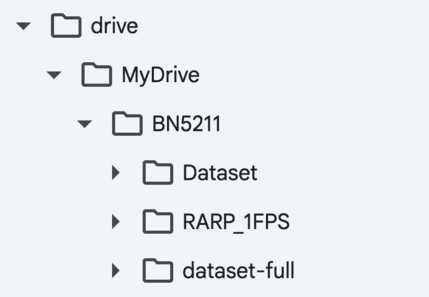

### Importing libraries

Please import the basic libraries and set the running device.

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torch.utils.data.dataset as Dataset
import torch.nn as nn

from PIL import Image
from torchvision import models

In [ ]:
if torch.cuda.is_available():
  device = 'cuda:0'  # choose your device here
else:
  device = 'cpu'
print('Using device:', device)

Using device: cuda:0


### Prepare dataset

Use the provided surgical-instrument dataset and the following data-loading code.

In [ ]:
path_train = os.path.join(dataset_root, 'train')
path_val = os.path.join(dataset_root, 'val')
path_test = os.path.join(dataset_root, 'test')

img_list_train = []
img_list_val = []
img_list_test = []

size_train = 0
size_val = 0
size_test = 0

# read all images' path
for root,dirs,files in os.walk(path_train):
  for file in files:
    img_list_train.append(os.path.join(root, file))
size_train = len(img_list_train)

for root,dirs,files in os.walk(path_val):
  for file in files:
    img_list_val.append(os.path.join(root, file))
size_val = len(img_list_val)

for root,dirs,files in os.walk(path_test):
  for file in files:
    img_list_test.append(os.path.join(root, file))
size_test = len(img_list_test)

In [ ]:
# define the data class
class ImageDataset(Dataset.Dataset):
  def __init__(self, img_list, is_train=True):
    self.img_list = img_list
    self.is_train = is_train
    self.augmentation_transforms = torchvision.transforms.Compose([
      torchvision.transforms.RandomHorizontalFlip(),
      torchvision.transforms.RandomVerticalFlip(),
      torchvision.transforms.RandomRotation(90)
    ])
    self.resize = torchvision.transforms.Resize((175, 300))
    self.image_transforms = torchvision.transforms.Compose([
      torchvision.transforms.ToTensor(),
      torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
      )
    ])
    self.label_dict = {
      'Bi': 0,
      'Cl': 1,
      'Gr': 2,
      'Ho': 3,
      'Ir': 4,
      'Sc': 5,
      'Sp': 6
    }

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    # image name looks like 'v01_007125_Gr.jpg'
    lab_value = self.img_list[index].split('_')[-1].split('.')[0]
    label = self.label_dict[lab_value]
    img_path = self.img_list[index]
    image = Image.open(img_path).convert('RGB')
    image = self.resize(image)

    # data augmentation for training
    if self.is_train:
      image = self.augmentation_transforms(image)

    image_tensor = self.image_transforms(image)
    image = np.array(image)
    label = torch.tensor(label, dtype=torch.long)

    return image, image_tensor, label


In [ ]:
# build dataset
dataset_train = ImageDataset(img_list_train, True)
dataset_val = ImageDataset(img_list_val, False)
dataset_test = ImageDataset(img_list_test, False)

To test and visualize the dataset loading.

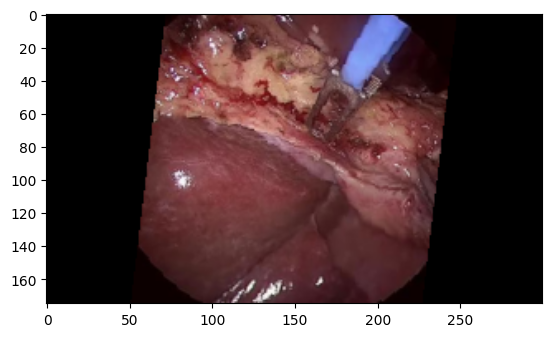

In [ ]:
# The visual result can be changed by changing the value of __getitem__(1)
image1, image_norm1, label1 = dataset_train.__getitem__(1)  # due to different random seed, the result may vary
plt.imshow(image1, interpolation='bilinear')
plt.show()

## Task 1: Building and analysing CNNs for surgical instrument classification [40%]

In this task, you will build a convolutional neural network to classify seven surgical instruments: Bipolar, Clipper, Grasper, Hook, Irrigator, Scissors, and Specimen Bag. You will first develop a baseline model, then explore how several design and training choices affect its performance.

Task 1 has two main parts: **Code Implementation [20%]** (Q1.1-1.3) and **Analysis Report [20%]** (Q1.4). You can also create your own visualizations in the indicated notebook cells so that you can decide how best to communicate your results.


### **[5%] Q1.1: Implement the baseline CNN**

A convolutional neural network (CNN) is one of the most widely used architectures for computer-vision tasks such as classification, segmentation and regression. If you are new to CNNs, this [gentle guide](https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53) is a good starting point.

Complete the `ConvNet` class below by following the TODOs. Use the layer names specified in the code (`conv1`–`conv5`, `bn1`–`bn5`, `relu1`–`relu5`, `max1`–`max5`, and `fc1`–`fc3`), because Task 3 reuses the convolutional weights by name. Refer to the [torch.nn documentation](https://pytorch.org/docs/stable/nn.html) for the individual building blocks.

In [ ]:
class ConvNet(torch.nn.Module):
  def __init__(self):
    super().__init__()

    ##############################################################################
    # TODO: Implement the CNN architecture described below.
    # Requirements:
    # - Use convolution, batch normalization, activation (ReLU), pooling,
    #   fully connected layers, and at least one regularization method (e.g., Dropout).
    # - Input:  (B, 3, 175, 300)
    # - Output: Class logits of shape (B, 7)
    ##############################################################################

    # Block 1: 3 x 175 x 300 --> 32 x 87 x 150
    # Define self.conv1, self.bn1, self.relu1, and self.max1
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.bn1 = nn.BatchNorm2d(32)
    self.relu1 = nn.ReLU()
    self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 2: 32 x 87 x 150 --> 64 x 43 x 75
    # Define self.conv2, self.bn2, self.relu2, and self.max2
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(64)
    self.relu2 = nn.ReLU()
    self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 3: 64 x 43 x 75 --> 128 x 21 x 37
    # Define self.conv3, self.bn3, self.relu3, and self.max3
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.bn3 = nn.BatchNorm2d(128)
    self.relu3 = nn.ReLU()
    self.max3 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 4: 128 x 21 x 37 --> 256 x 10 x 18
    # Define self.conv4, self.bn4, self.relu4, and self.max4
    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
    self.bn4 = nn.BatchNorm2d(256)
    self.relu4 = nn.ReLU()
    self.max4 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 5: 256 x 10 x 18 --> 256 x 5 x 9
    # Define self.conv5, self.bn5, self.relu5, and self.max5
    self.conv5 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
    self.bn5 = nn.BatchNorm2d(256)
    self.relu5 = nn.ReLU()
    self.max5 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Fully connected layers: 256 x 5 x 9 --> 2048 --> 1024 --> 7
    # Define self.fc1, self.fc2, and self.fc3
    self.fc1 = nn.Linear(256 * 5 * 9, 2048)
    self.fc2 = nn.Linear(2048, 1024)
    self.fc3 = nn.Linear(1024, 7)

    # Dropout layer(s)
    self.dropout = nn.Dropout(p=0.5)

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################

  def forward(self, x):
    ##############################################################################
    # TODO: Implement the forward pass.
    # - Pass the input through the convolutional blocks.
    # - Flatten the feature map.
    # - Apply fully connected layers with dropout.
    # - Return class logits.
    ##############################################################################

    # Block 1:         3 x 175 x 300 --> 32 x 87 x 150
    x = self.max1(self.relu1(self.bn1(self.conv1(x))))


    # Block 2:         32 x 87 x 150 --> 64 x 43 x 75
    x = self.max2(self.relu2(self.bn2(self.conv2(x))))


    # Block 3:         64 x 43 x 75 --> 128 x 21 x 37
    x = self.max3(self.relu3(self.bn3(self.conv3(x))))


    # Block 4:         128 x 21 x 37 --> 256 x 10 x 18
    x = self.max4(self.relu4(self.bn4(self.conv4(x))))


    # Block 5:         256 x 10 x 18 --> 256 x 5 x 9
    x = self.max5(self.relu5(self.bn5(self.conv5(x))))


    # Linear layers:   256 x 5 x 9 --> 11520 --> 2048 --> 1024 --> 7
    # Apply fc layers with dropout
    x = torch.flatten(x, start_dim=1)
    x = self.dropout(torch.relu(self.fc1(x)))
    x = self.dropout(torch.relu(self.fc2(x)))
    x = self.fc3(x)  # Return raw logits for CrossEntropyLoss.

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################
    return x


model = ConvNet().to(device)
summary(model, input_size=(1, 3, 175, 300))

Layer (type:depth-idx)                   Output Shape              Param #
ConvNet                                  [1, 7]                    --
├─Conv2d: 1-1                            [1, 32, 175, 300]         896
├─BatchNorm2d: 1-2                       [1, 32, 175, 300]         64
├─ReLU: 1-3                              [1, 32, 175, 300]         --
├─MaxPool2d: 1-4                         [1, 32, 87, 150]          --
├─Conv2d: 1-5                            [1, 64, 87, 150]          18,496
├─BatchNorm2d: 1-6                       [1, 64, 87, 150]          128
├─ReLU: 1-7                              [1, 64, 87, 150]          --
├─MaxPool2d: 1-8                         [1, 64, 43, 75]           --
├─Conv2d: 1-9                            [1, 128, 43, 75]          73,856
├─BatchNorm2d: 1-10                      [1, 128, 43, 75]          256
├─ReLU: 1-11                             [1, 128, 43, 75]          --
├─MaxPool2d: 1-12                        [1, 128, 21, 37]          --
├─Co

### **[5%] Q1.2: Implement the training and evaluation pipeline**

Next, complete the training and evaluation functions for your baseline model. Please record the training and validation results needed for the later analysis; the test set should remain unused in this section.

In [ ]:
# Baseline training configuration
batch_size = 8
criterion = torch.nn.CrossEntropyLoss()

dataloader_train = torch.utils.data.DataLoader(
  dataset_train, batch_size=batch_size, shuffle=True
)
dataloader_val = torch.utils.data.DataLoader(
  dataset_val, batch_size=batch_size, shuffle=False
)

dataloader_test = torch.utils.data.DataLoader(
  dataset_test, batch_size=batch_size, shuffle=False
)

To support your later analysis, please record training loss, training accuracy, validation loss, and validation accuracy for every epoch. Save the checkpoint with the highest validation accuracy and record the complete training history appropriately.

Your evaluation function should return the loss, accuracy, ground-truth labels, predicted labels, and class probabilities. You will use these outputs later to examine class-level performance and individual predictions.

In [ ]:
def train_net(model, dataloader_train, dataloader_val, optimizer,
              criterion, save_path, total_epochs=200):
  ##############################################################################
  # TODO: Implement training and validation.
  # Requirements:
  # - For each training batch: move data to device, zero gradients, run
  #   forward pass, compute loss, backpropagate, and update parameters.
  # - Compute sample-weighted training loss and accuracy for each epoch.
  # - Evaluate on the validation set at the end of each epoch.
  # - Save the checkpoint with the highest validation accuracy.
  # - Return a history dictionary with keys:
  #   'train_loss', 'train_accuracy', 'val_loss', and 'val_accuracy'.
  # - Do not access the test set and do not generate plots here.
  ##############################################################################

  history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
  }
  best_val_accuracy = -1.0
  os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)

  for epoch in range(total_epochs):
    # Validation switches to eval mode, so restore training mode each epoch.
    model.train()
    running_loss = 0.0
    correct = 0
    sample_count = 0

    for _, images, labels in dataloader_train:
      images = images.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()
      logits = model(images)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()

      # Weight the batch mean by its size, including the smaller last batch.
      batch_count = labels.size(0)
      running_loss += loss.item() * batch_count
      correct += (logits.argmax(dim=1) == labels).sum().item()
      sample_count += batch_count

    if sample_count == 0:
      raise ValueError('The training dataloader contains no samples.')

    train_loss = running_loss / sample_count
    train_accuracy = correct / sample_count
    val_results = eval_on_dataset(model, dataloader_val)

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_loss'].append(val_results['loss'])
    history['val_accuracy'].append(val_results['accuracy'])

    # Keep the first checkpoint attaining the highest validation accuracy.
    if val_results['accuracy'] > best_val_accuracy:
      best_val_accuracy = val_results['accuracy']
      torch.save(model.state_dict(), save_path)

    print(
      f"Epoch {epoch + 1:03d}/{total_epochs} | "
      f"train loss: {train_loss:.4f}, accuracy: {train_accuracy:.4f} | "
      f"val loss: {val_results['loss']:.4f}, "
      f"accuracy: {val_results['accuracy']:.4f}"
    )

  return history

  ##############################################################################
  #                         END OF YOUR CODE
  ##############################################################################


In [ ]:
@torch.inference_mode()
def eval_on_dataset(model, dataloader):
  ##############################################################################
  # TODO: Implement evaluation.
  # Requirements:
  # - Use model.eval() and do not compute gradients.
  # - Compute sample-weighted average loss and accuracy.
  # - Collect all ground-truth labels, predicted labels, and probabilities.
  # - Return a dictionary with keys:
  #   'loss', 'accuracy', 'labels', 'predictions', and 'probabilities'.
  ##############################################################################

  model.eval()
  total_loss = 0.0
  correct = 0
  sample_count = 0
  all_labels = []
  all_predictions = []
  all_probabilities = []

  for _, images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)
    logits = model(images)

    # Sum unweighted cross-entropy, matching Task 1's training criterion.
    total_loss += F.cross_entropy(logits, labels, reduction='sum').item()
    probabilities = torch.softmax(logits, dim=1)
    predictions = logits.argmax(dim=1)
    correct += (predictions == labels).sum().item()
    sample_count += labels.size(0)

    all_labels.append(labels.cpu())
    all_predictions.append(predictions.cpu())
    all_probabilities.append(probabilities.cpu())

  if sample_count == 0:
    raise ValueError('The evaluation dataloader contains no samples.')

  return {
    'loss': total_loss / sample_count,
    'accuracy': correct / sample_count,
    'labels': torch.cat(all_labels).numpy(),
    'predictions': torch.cat(all_predictions).numpy(),
    'probabilities': torch.cat(all_probabilities).numpy(),
  }

  ##############################################################################
  #                         END OF YOUR CODE
  ##############################################################################


Train the baseline model using SGD and batch size 8, then save its training history and best-validation checkpoint for Q1.3. As a simple debugging check, validation accuracy would normally exceed 55%; this is only a guide and not a grading threshold.

In [ ]:
# C0: baseline CNN, random initialization, SGD, batch size 8
epochs = 200
learning_rate = 0.001

model_c0 = ConvNet().to(device)
optimizer_c0 = optim.SGD(model_c0.parameters(), lr=learning_rate)

os.makedirs(weights_root, exist_ok=True)
save_path_c0 = os.path.join(weights_root, 'task1_c0_baseline_sgd_bs8.pth')

##############################################################################
# TODO: Train C0 and store its returned history for later visualization.
##############################################################################

history_c0 = train_net(
  model_c0,
  dataloader_train,
  dataloader_val,
  optimizer_c0,
  criterion,
  save_path_c0,
  total_epochs=epochs,
)

# Persist the curves' numerical data for Q1.3 and the analysis report.
import json

history_path_c0 = os.path.join(weights_root, 'task1_c0_history.json')
with open(history_path_c0, 'w', encoding='utf-8') as history_file:
  json.dump(history_c0, history_file, indent=2)

best_epoch_c0 = int(np.argmax(history_c0['val_accuracy'])) + 1
print(
  f"C0 best validation accuracy: {max(history_c0['val_accuracy']):.4f} "
  f"at epoch {best_epoch_c0}"
)
print(f'Best checkpoint: {save_path_c0}')
print(f'Training history: {history_path_c0}')

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Epoch 001/200 | train loss: 1.9859, accuracy: 0.1011 | val loss: 1.9455, accuracy: 0.0909
Epoch 002/200 | train loss: 1.9464, accuracy: 0.1461 | val loss: 1.9247, accuracy: 0.2121
Epoch 003/200 | train loss: 1.9469, accuracy: 0.1854 | val loss: 1.9038, accuracy: 0.2424
Epoch 004/200 | train loss: 1.9233, accuracy: 0.1742 | val loss: 1.8943, accuracy: 0.2727
Epoch 005/200 | train loss: 1.9281, accuracy: 0.1629 | val loss: 1.8817, accuracy: 0.3030
Epoch 006/200 | train loss: 1.8995, accuracy: 0.1910 | val loss: 1.8753, accuracy: 0.3030
Epoch 007/200 | train loss: 1.8970, accuracy: 0.1685 | val loss: 1.8708, accuracy: 0.3939
Epoch 008/200 | train loss: 1.8685, accuracy: 0.2247 | val loss: 1.8506, accuracy: 0.3333
Epoch 009/200 | train loss: 1.8697, accuracy: 0.2697 | val loss: 1.8368, accuracy: 0.2424
Epoch 010/200 | train loss: 1.8371, accuracy: 0.2697 | val loss: 1.8229, accuracy: 0.1818
Epoch 011/200 | train loss: 1.8147, accuracy: 0.2697 | val loss: 1.8070, accuracy: 0.2424
Epoch 012/

#### Explore the baseline training process

Use the cell below to create your own visualizations of the baseline training process. At minimum, your report should include clearly labelled training and validation loss and accuracy curves, but you are free to choose the layout and presentation that communicate the results most effectively.


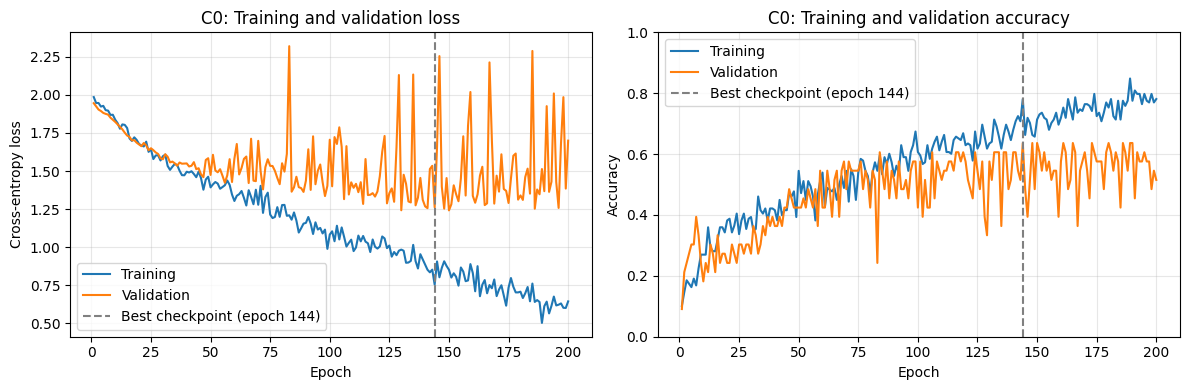

In [ ]:
##############################################################################
# TODO: Design and implement visualizations of the C0 training and
# validation history. You may add additional cells if needed.
##############################################################################

epoch_numbers = np.arange(1, len(history_c0['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epoch_numbers, history_c0['train_loss'], label='Training')
axes[0].plot(epoch_numbers, history_c0['val_loss'], label='Validation')
axes[0].set_title('C0: Training and validation loss')
axes[0].set_ylabel('Cross-entropy loss')

axes[1].plot(epoch_numbers, history_c0['train_accuracy'], label='Training')
axes[1].plot(epoch_numbers, history_c0['val_accuracy'], label='Validation')
axes[1].set_title('C0: Training and validation accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)

for ax in axes:
  ax.axvline(best_epoch_c0, color='gray', linestyle='--',
             label=f'Best checkpoint (epoch {best_epoch_c0})')
  ax.set_xlabel('Epoch')
  ax.grid(alpha=0.3)
  ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(weights_root, 'task1_c0_learning_curves.png'),
            dpi=200, bbox_inches='tight')
plt.show()

##############################################################################
#                         END OF YOUR CODE
##############################################################################


### **[10%] Q1.3: Implement and run the controlled comparisons**

You will now explore how four factors affect model performance:

1. **Architecture:** baseline CNN versus custom ResNet18.
2. **Optimizer:** SGD versus Adam.
3. **Batch size:** 8 versus 16.
4. **Initialization:** randomly initialized versus ImageNet-pretrained torchvision ResNet18.

Please use the configurations below so that only one intended factor changes within each comparison:

| ID | Architecture | Initialization | Optimizer | Batch size | Comparison |
|---|---|---|---|---:|---|
| C0 | Baseline CNN | Random | SGD | 8 | Baseline |
| C1 | Custom ResNet18 | Random | SGD | 8 | C0 vs. C1: architecture |
| C2 | Custom ResNet18 | Random | Adam | 8 | C1 vs. C2: optimizer |
| C3 | Custom ResNet18 | Random | Adam | 16 | C2 vs. C3: batch size |
| C4 | Torchvision ResNet18 | Random | Adam | 16 | Initialization reference |
| C5 | Torchvision ResNet18 | ImageNet | Adam | 16 | C4 vs. C5: initialization |

To keep the comparisons meaningful, use the same learning rate, epoch numbers, data split, preprocessing, and checkpoint-selection rule within each comparison. Save the history and checkpoint for each configuration separately, use validation results for comparison, and leave the test set untouched until the final model has been selected.


In [ ]:
# Define a custom ResNet18 without using torchvision.models.

class ResNet18Custom(torch.nn.Module):
    ##############################################################################
    # TODO: Implement a ResNet-18 from scratch (without torchvision.models).
    # - Refer to He et al., CVPR 2016 (arXiv:1512.03385).
    # - You may consult the official PyTorch implementation:
    #   https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py
    # - Do not copy-paste; instead, understand the architecture and write
    #   your own implementation.
    ##############################################################################

    def __init__(self, num_classes=7):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        # Four stages, each containing two basic residual blocks: [2, 2, 2, 2].
        self.stage1 = nn.Sequential(ResidualBlock(64, 64), ResidualBlock(64, 64))
        self.stage2 = nn.Sequential(ResidualBlock(64, 128, stride=2),
                                    ResidualBlock(128, 128))
        self.stage3 = nn.Sequential(ResidualBlock(128, 256, stride=2),
                                    ResidualBlock(256, 256))
        self.stage4 = nn.Sequential(ResidualBlock(256, 512, stride=2),
                                    ResidualBlock(512, 512))
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.kaiming_normal_(layer.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(layer, nn.BatchNorm2d):
                nn.init.ones_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        return self.fc(torch.flatten(x, start_dim=1))


class ResidualBlock(nn.Module):
    ##############################################################################
    # TODO: Implement a basic residual block, including the shortcut needed
    # when the spatial resolution or number of channels changes.
    ##############################################################################

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        # Match both spatial size and channels before residual addition.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        features = self.relu(self.bn1(self.conv1(x)))
        features = self.bn2(self.conv2(features))
        return self.relu(features + identity)

##############################################################################
# TODO: Print the custom ResNet18 summary and verify its output shape.
##############################################################################

# Use a disposable CPU model so this check does not occupy accelerator memory.
shape_check_model = ResNet18Custom().eval()
summary(shape_check_model, input_size=(1, 3, 175, 300), device='cpu')
with torch.inference_mode():
    shape_check_output = shape_check_model(torch.zeros(2, 3, 175, 300))
assert shape_check_output.shape == (2, 7)
print('Custom ResNet18 output shape:', tuple(shape_check_output.shape))
del shape_check_model, shape_check_output


##############################################################################
#                 END OF YOUR CODE
##############################################################################

Custom ResNet18 output shape: (2, 7)


In [ ]:
# C1: custom ResNet18, random initialization, SGD, batch size 8
##############################################################################
# TODO: Train C1 using the same SGD settings, batch size, epoch budget,
# and validation protocol as C0. Save its history and best checkpoint.
##############################################################################

import json
import random

# Reuse C0's learning rate, epoch budget, preprocessing and validation rule.
task1_learning_rate = learning_rate
task1_epochs = epochs
if len(history_c0['val_accuracy']) != task1_epochs:
    raise ValueError('C0 and C1-C5 must use the same epoch budget.')
task1_seed = 42

def seed_task1(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_task1_configuration(config_id, model_factory, optimizer_name,
                            train_batch_size):
    seed_task1(task1_seed)
    current_model = model_factory().to(device)
    if optimizer_name == 'SGD':
        current_optimizer = optim.SGD(current_model.parameters(),
                                      lr=task1_learning_rate)
    elif optimizer_name == 'Adam':
        current_optimizer = optim.Adam(current_model.parameters(),
                                       lr=task1_learning_rate)
    else:
        raise ValueError(f'Unsupported optimizer: {optimizer_name}')

    # Separate generators keep shuffle order independent of model creation.
    shuffle_generator = torch.Generator().manual_seed(task1_seed)
    train_loader = torch.utils.data.DataLoader(
        dataset_train, batch_size=train_batch_size, shuffle=True,
        generator=shuffle_generator,
    )
    val_loader = torch.utils.data.DataLoader(
        dataset_val, batch_size=8, shuffle=False,
    )
    # Reset augmentation randomness after model initialization.
    seed_task1(task1_seed)
    checkpoint_path = os.path.join(weights_root,
                                   f'task1_{config_id.lower()}_best.pth')
    current_history = train_net(
        current_model, train_loader, val_loader, current_optimizer,
        criterion, checkpoint_path, total_epochs=task1_epochs,
    )
    history_path = os.path.join(weights_root,
                                f'task1_{config_id.lower()}_history.json')
    with open(history_path, 'w', encoding='utf-8') as file:
        json.dump(current_history, file, indent=2)
    print(f'{config_id}: best validation accuracy = '
          f"{max(current_history['val_accuracy']):.4f}")
    # Only histories and checkpoints are needed for comparison.
    del current_optimizer, current_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return current_history, checkpoint_path


# C0 was trained in Q1.2; its weights remain available on disk.
# Release its accelerator storage before the following independent runs.
model_c0.cpu()
history_c1, save_path_c1 = run_task1_configuration(
    'C1', ResNet18Custom, 'SGD', 8,
)

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Epoch 001/200 | train loss: 1.9777, accuracy: 0.1404 | val loss: 1.9605, accuracy: 0.1212
Epoch 002/200 | train loss: 1.9463, accuracy: 0.1404 | val loss: 1.9416, accuracy: 0.1212
Epoch 003/200 | train loss: 1.9498, accuracy: 0.1236 | val loss: 1.9303, accuracy: 0.2424
Epoch 004/200 | train loss: 1.9319, accuracy: 0.1348 | val loss: 1.9130, accuracy: 0.2727
Epoch 005/200 | train loss: 1.9351, accuracy: 0.1629 | val loss: 1.8979, accuracy: 0.2424
Epoch 006/200 | train loss: 1.9211, accuracy: 0.2135 | val loss: 1.8964, accuracy: 0.2121
Epoch 007/200 | train loss: 1.9072, accuracy: 0.2247 | val loss: 1.8840, accuracy: 0.3333
Epoch 008/200 | train loss: 1.8801, accuracy: 0.2416 | val loss: 1.8716, accuracy: 0.3030
Epoch 009/200 | train loss: 1.8858, accuracy: 0.2472 | val loss: 1.8695, accuracy: 0.3333
Epoch 010/200 | train loss: 1.8792, accuracy: 0.2472 | val loss: 1.8578, accuracy: 0.2727
Epoch 011/200 | train loss: 1.8641, accuracy: 0.2865 | val loss: 1.8454, accuracy: 0.3030
Epoch 012/

In [ ]:
# C2: custom ResNet18, random initialization, Adam, batch size 8
##############################################################################
# TODO: Train C2. Change only the optimizer relative to C1 and save its
# history and best-validation checkpoint separately.
##############################################################################

# The same seed gives C1 and C2 the same initial custom-network weights.
history_c2, save_path_c2 = run_task1_configuration(
    'C2', ResNet18Custom, 'Adam', 8,
)

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Epoch 001/200 | train loss: 2.1890, accuracy: 0.1966 | val loss: 6.0211, accuracy: 0.1212
Epoch 002/200 | train loss: 1.8735, accuracy: 0.2191 | val loss: 3.0025, accuracy: 0.2121
Epoch 003/200 | train loss: 1.8610, accuracy: 0.2697 | val loss: 4.9691, accuracy: 0.2121
Epoch 004/200 | train loss: 1.7466, accuracy: 0.3258 | val loss: 1.9661, accuracy: 0.2424
Epoch 005/200 | train loss: 1.6130, accuracy: 0.3820 | val loss: 2.2231, accuracy: 0.2727
Epoch 006/200 | train loss: 1.6084, accuracy: 0.3652 | val loss: 1.7919, accuracy: 0.3333
Epoch 007/200 | train loss: 1.6053, accuracy: 0.3876 | val loss: 1.9689, accuracy: 0.3333
Epoch 008/200 | train loss: 1.5562, accuracy: 0.3820 | val loss: 2.8148, accuracy: 0.3030
Epoch 009/200 | train loss: 1.6464, accuracy: 0.3652 | val loss: 2.4495, accuracy: 0.2424
Epoch 010/200 | train loss: 1.6696, accuracy: 0.3652 | val loss: 1.8170, accuracy: 0.4545
Epoch 011/200 | train loss: 1.5123, accuracy: 0.4270 | val loss: 1.7174, accuracy: 0.3939
Epoch 012/

In [ ]:
# C3: custom ResNet18, random initialization, Adam, batch size 16
##############################################################################
# TODO: Rebuild the training dataloader with batch size 16 and train C3.
# Change only the batch size relative to C2. Save its history and best
# validation checkpoint separately.
##############################################################################

history_c3, save_path_c3 = run_task1_configuration(
    'C3', ResNet18Custom, 'Adam', 16,
)

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Epoch 001/200 | train loss: 2.2071, accuracy: 0.2135 | val loss: 15.8541, accuracy: 0.1212
Epoch 002/200 | train loss: 1.8208, accuracy: 0.2472 | val loss: 7.1160, accuracy: 0.1818
Epoch 003/200 | train loss: 1.8596, accuracy: 0.2640 | val loss: 6.8387, accuracy: 0.1818
Epoch 004/200 | train loss: 1.6685, accuracy: 0.3764 | val loss: 12.0948, accuracy: 0.1212
Epoch 005/200 | train loss: 1.6846, accuracy: 0.3483 | val loss: 4.4707, accuracy: 0.2424
Epoch 006/200 | train loss: 1.5881, accuracy: 0.3483 | val loss: 2.3489, accuracy: 0.3030
Epoch 007/200 | train loss: 1.4488, accuracy: 0.3820 | val loss: 2.6407, accuracy: 0.3030
Epoch 008/200 | train loss: 1.4908, accuracy: 0.4270 | val loss: 3.0575, accuracy: 0.2424
Epoch 009/200 | train loss: 1.4673, accuracy: 0.4438 | val loss: 2.2565, accuracy: 0.3030
Epoch 010/200 | train loss: 1.6563, accuracy: 0.3539 | val loss: 2.1129, accuracy: 0.3030
Epoch 011/200 | train loss: 1.4840, accuracy: 0.4382 | val loss: 3.1139, accuracy: 0.1212
Epoch 01

For the final comparison, you will investigate how weight initialization affects model performance. Train two torchvision ResNet18 models using the same architecture and supervised training protocol: one with randomly initialized weights and one with ImageNet-pretrained weights.

Using a model pretrained on one dataset and adapting it to a new task is known as transfer learning technique. Here, you will replace the pretrained ResNet18 classification layer with a seven-class classifier and fine-tune the model for surgical instrument classification. The pre-trained model can be obtained from the PyTorch library. Furthermore, this technique can also help you adapt the newest-trend foundation into downstream tasks, which can save you a lot of time and computational resources.

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

# C4: torchvision ResNet18, random initialization, Adam, batch size 16
##############################################################################
# TODO: Train a ResNet18 from torchvision without pretrained weights.
# - Initialize ResNet18 with random weights (weights=None).
# - Replace its final classifier with a 7-class linear layer.
# - Train it using the same protocol that will be used for C5.
# - Save its history and best-validation checkpoint separately.
###############################################################################

def build_task1_torchvision_resnet(weights=None):
    network = resnet18(weights=weights)
    # Use the same randomly initialized 7-class head for C4 and C5.
    torch.manual_seed(task1_seed)
    network.fc = nn.Linear(network.fc.in_features, 7)
    # Fine-tune all layers; neither model freezes its backbone.
    return network


history_c4, save_path_c4 = run_task1_configuration(
    'C4', lambda: build_task1_torchvision_resnet(weights=None), 'Adam', 16,
)

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Epoch 001/200 | train loss: 2.1809, accuracy: 0.1742 | val loss: 30.3798, accuracy: 0.1212
Epoch 002/200 | train loss: 1.8359, accuracy: 0.2528 | val loss: 43.6771, accuracy: 0.1818
Epoch 003/200 | train loss: 1.7102, accuracy: 0.2921 | val loss: 10.0368, accuracy: 0.2424
Epoch 004/200 | train loss: 1.6298, accuracy: 0.3427 | val loss: 11.1408, accuracy: 0.1212
Epoch 005/200 | train loss: 1.7734, accuracy: 0.3427 | val loss: 10.2233, accuracy: 0.1515
Epoch 006/200 | train loss: 1.5950, accuracy: 0.3764 | val loss: 2.5904, accuracy: 0.3333
Epoch 007/200 | train loss: 1.5221, accuracy: 0.3483 | val loss: 2.0372, accuracy: 0.4242
Epoch 008/200 | train loss: 1.5074, accuracy: 0.4382 | val loss: 2.1075, accuracy: 0.3636
Epoch 009/200 | train loss: 1.3882, accuracy: 0.4607 | val loss: 2.5526, accuracy: 0.3333
Epoch 010/200 | train loss: 1.5409, accuracy: 0.4101 | val loss: 1.9769, accuracy: 0.3333
Epoch 011/200 | train loss: 1.3604, accuracy: 0.4719 | val loss: 2.6726, accuracy: 0.2727
Epoch

In [ ]:
# C5: torchvision ResNet18, ImageNet initialization, Adam, batch size 16
##############################################################################
# TODO:
# - Initialize ResNet18 with pretrained weights on ImageNet (weights=ResNet18_Weights.DEFAULT).
# - Replace its final classifier with a 7-class linear layer.
# - Use exactly the same supervised training protocol as C4.
# - Save its history and best-validation checkpoint separately.
##############################################################################

history_c5, save_path_c5 = run_task1_configuration(
    'C5',
    lambda: build_task1_torchvision_resnet(weights=ResNet18_Weights.DEFAULT),
    'Adam', 16,
)

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Epoch 001/200 | train loss: 1.7293, accuracy: 0.3258 | val loss: 8.5877, accuracy: 0.2121
Epoch 002/200 | train loss: 1.4556, accuracy: 0.5169 | val loss: 28.6192, accuracy: 0.1515
Epoch 003/200 | train loss: 1.0000, accuracy: 0.6180 | val loss: 11.5109, accuracy: 0.1818
Epoch 004/200 | train loss: 1.0604, accuracy: 0.6236 | val loss: 4.7387, accuracy: 0.2424
Epoch 005/200 | train loss: 1.0090, accuracy: 0.6461 | val loss: 2.7952, accuracy: 0.3333
Epoch 006/200 | train loss: 1.0300, accuracy: 0.6011 | val loss: 1.5399, accuracy: 0.5455
Epoch 007/200 | train loss: 0.9432, accuracy: 0.6854 | val loss: 0.9081, accuracy: 0.6364
Epoch 008/200 | train loss: 0.5882, accuracy: 0.7865 | val loss: 1.0706, accuracy: 0.6364
Epoch 009/200 | train loss: 0.5427, accuracy: 0.8371 | val loss: 1.1147, accuracy: 0.7273
Epoch 010/200 | train loss: 0.7332, accuracy: 0.7697 | val loss: 1.4138, accuracy: 0.6061
Epoch 011/200 | train loss: 0.5732, accuracy: 0.7921 | val loss: 1.3232, accuracy: 0.6364
Epoch 01

#### Select and evaluate your final model

Review the validation results from C0–C5 and select the final configuration before accessing the test set. Once your choice has been recorded, load its best-validation checkpoint and evaluate it on the test set.


In [ ]:
##############################################################################
# TODO: Select the final configuration using validation evidence only.
# Then load its best checkpoint and evaluate dataloader_test exactly once.
# Retain the returned labels, predictions, etc. for Q1.4.
##############################################################################

import hashlib

# Freeze the decision using validation evidence before any test evaluation.
task1_histories = {
    'C0': history_c0, 'C1': history_c1, 'C2': history_c2,
    'C3': history_c3, 'C4': history_c4, 'C5': history_c5,
}
task1_checkpoints = {
    'C0': save_path_c0, 'C1': save_path_c1, 'C2': save_path_c2,
    'C3': save_path_c3, 'C4': save_path_c4, 'C5': save_path_c5,
}
validation_summary = []
for config_id, history in task1_histories.items():
    # train_net retains the first epoch achieving the maximum accuracy.
    best_index = int(np.argmax(history['val_accuracy']))
    validation_summary.append({
        'configuration': config_id,
        'best_epoch': best_index + 1,
        'val_accuracy': float(history['val_accuracy'][best_index]),
        'val_loss': float(history['val_loss'][best_index]),
    })

# Highest validation accuracy; ties use lower loss at the saved epoch,
# then configuration ID for a deterministic final tie-break.
winner = min(validation_summary,
             key=lambda row: (-row['val_accuracy'], row['val_loss'],
                              row['configuration']))
selected_configuration = winner['configuration']
selected_checkpoint = task1_checkpoints[selected_configuration]
print('Validation summary:', validation_summary)
print('Selected configuration (validation only):', winner)

if selected_configuration == 'C0':
    final_model = ConvNet()
elif selected_configuration in ('C1', 'C2', 'C3'):
    final_model = ResNet18Custom()
else:
    # The saved checkpoint already contains all trained weights.
    final_model = build_task1_torchvision_resnet(weights=None)
final_model.load_state_dict(torch.load(selected_checkpoint,
                                       map_location='cpu', weights_only=True))
final_model = final_model.to(device)
final_model.eval()

# Cache the final predictions so rerunning this cell does not retest a model.
selection_path = os.path.join(weights_root, 'task1_final_selection.json')
test_results_path = os.path.join(weights_root, 'task1_final_test_results.npz')
checkpoint_hash = hashlib.sha256()
with open(selected_checkpoint, 'rb') as file:
    for chunk in iter(lambda: file.read(1024 * 1024), b''):
        checkpoint_hash.update(chunk)
selection_record = {
    'selected_configuration': selected_configuration,
    'checkpoint_sha256': checkpoint_hash.hexdigest(),
    'validation_summary': validation_summary,
    'selection_rule': 'max validation accuracy, then min loss, then ID',
}
if os.path.exists(selection_path):
    with open(selection_path, encoding='utf-8') as file:
        previous_selection = json.load(file)
    if previous_selection != selection_record:
        raise RuntimeError('The recorded final selection is locked. Do not '
                           'reselect a model after inspecting test results.')
if os.path.exists(test_results_path) and not os.path.exists(selection_path):
    raise RuntimeError('Test results exist without their selection record.')

# Persist the choice before accessing the test set.
with open(selection_path, 'w', encoding='utf-8') as file:
    json.dump(selection_record, file, indent=2)
if os.path.exists(test_results_path):
    with np.load(test_results_path, allow_pickle=False) as saved:
        task1_test_results = {key: saved[key].copy() for key in saved.files}
    task1_test_results['loss'] = float(task1_test_results['loss'])
    task1_test_results['accuracy'] = float(task1_test_results['accuracy'])
    print('Using saved final test predictions; no new test evaluation.')
else:
    task1_test_results = eval_on_dataset(final_model, dataloader_test)
    # Preserve prediction-to-image order across notebook restarts.
    task1_test_results['image_paths'] = np.asarray(
        dataloader_test.dataset.img_list, dtype=str,
    )
    np.savez_compressed(test_results_path, **task1_test_results)
print(f"Final test loss: {task1_test_results['loss']:.4f}; "
      f"accuracy: {task1_test_results['accuracy']:.4f}")

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Validation summary: [{'configuration': 'C0', 'best_epoch': 144, 'val_accuracy': 0.6363636363636364, 'val_loss': 1.2616000459952788}, {'configuration': 'C1', 'best_epoch': 157, 'val_accuracy': 0.6666666666666666, 'val_loss': 1.4023166849757687}, {'configuration': 'C2', 'best_epoch': 129, 'val_accuracy': 0.8181818181818182, 'val_loss': 1.0159140988773399}, {'configuration': 'C3', 'best_epoch': 100, 'val_accuracy': 0.7878787878787878, 'val_loss': 1.105750705708157}, {'configuration': 'C4', 'best_epoch': 146, 'val_accuracy': 0.8484848484848485, 'val_loss': 1.0402054184426863}, {'configuration': 'C5', 'best_epoch': 152, 'val_accuracy': 0.9393939393939394, 'val_loss': 0.2304727855053815}]
Selected configuration (validation only): {'configuration': 'C5', 'best_epoch': 152, 'val_accuracy': 0.9393939393939394, 'val_loss': 0.2304727855053815}
Final test loss: 1.0053; accuracy: 0.7556


#### Prepare your Task 1 results

Use the cell below to create the figures and numerical summaries needed for your Q1.4 Analysis Report. You may organize them in any clear and appropriate way, and you are welcome to add more cells if needed.


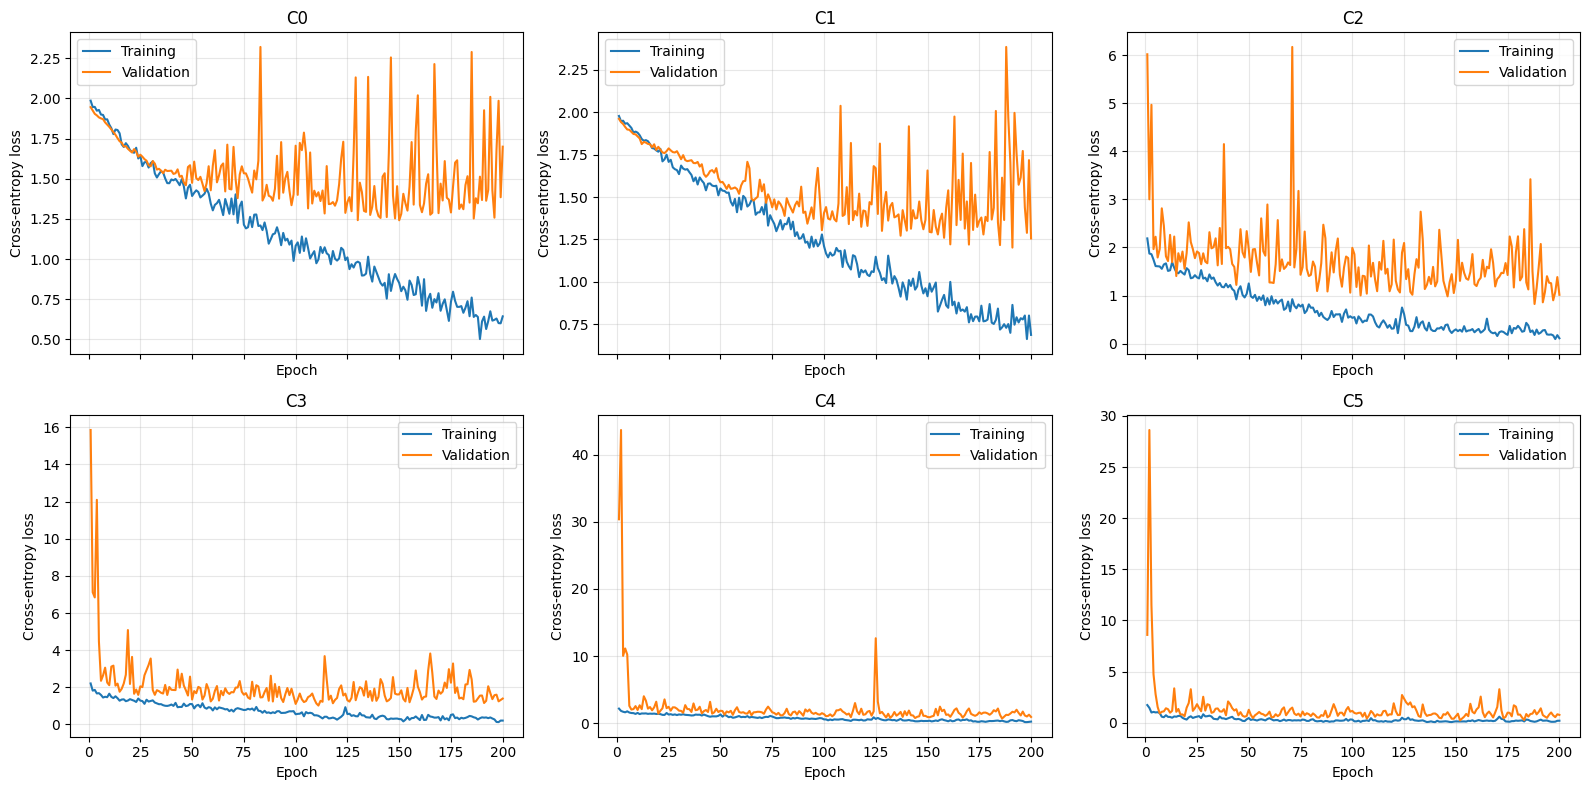

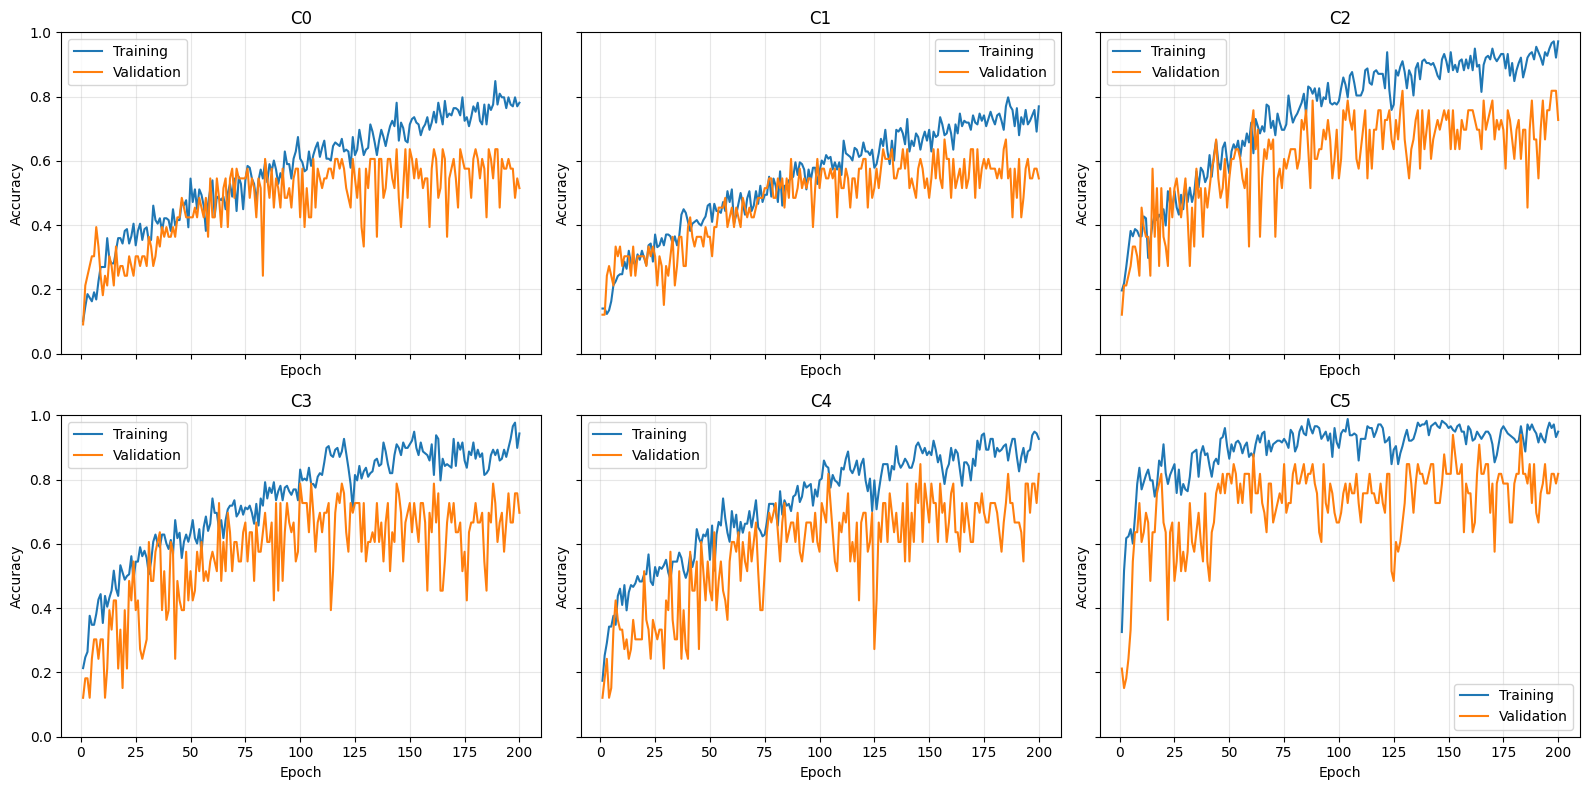

configuration | best_epoch | val_accuracy | val_loss
C0 | 144 | 0.6364 | 1.2616
C1 | 157 | 0.6667 | 1.4023
C2 | 129 | 0.8182 | 1.0159
C3 | 100 | 0.7879 | 1.1058
C4 | 146 | 0.8485 | 1.0402
C5 | 152 | 0.9394 | 0.2305
factor | comparison | before_val_accuracy | after_val_accuracy | accuracy_change_percentage_points | val_loss_change
Architecture | C0 -> C1 | 0.6364 | 0.6667 | 3.0303 | 0.1407
Optimizer | C1 -> C2 | 0.6667 | 0.8182 | 15.1515 | -0.3864
Batch size | C2 -> C3 | 0.8182 | 0.7879 | -3.0303 | 0.0898
Initialization | C4 -> C5 | 0.8485 | 0.9394 | 9.0909 | -0.8097
              precision    recall  f1-score   support

     Bipolar     1.0000    0.7333    0.8462        15
     Clipper     0.4500    0.7500    0.5625        12
     Grasper     0.8462    0.7857    0.8148        14
        Hook     0.6154    0.5714    0.5926        14
   Irrigator     1.0000    0.9333    0.9655        15
    Scissors     0.8000    0.7273    0.7619        11
 SpecimenBag     0.7778    0.7778    0.7778     

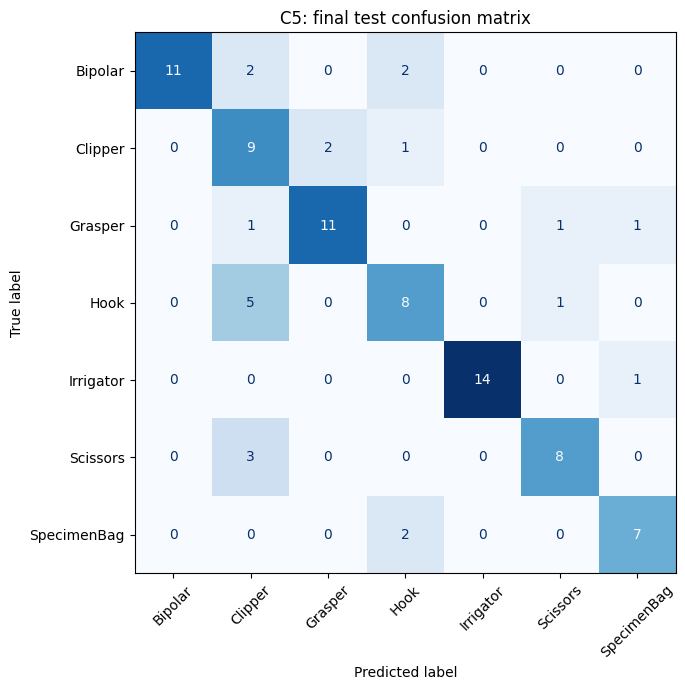

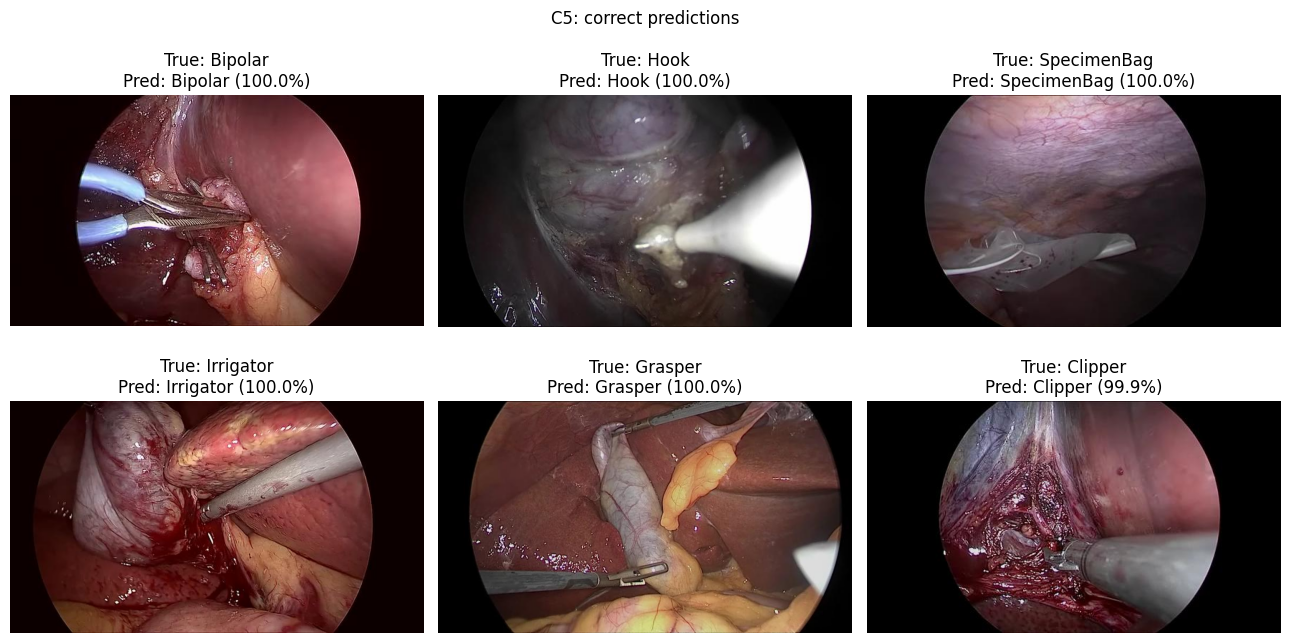

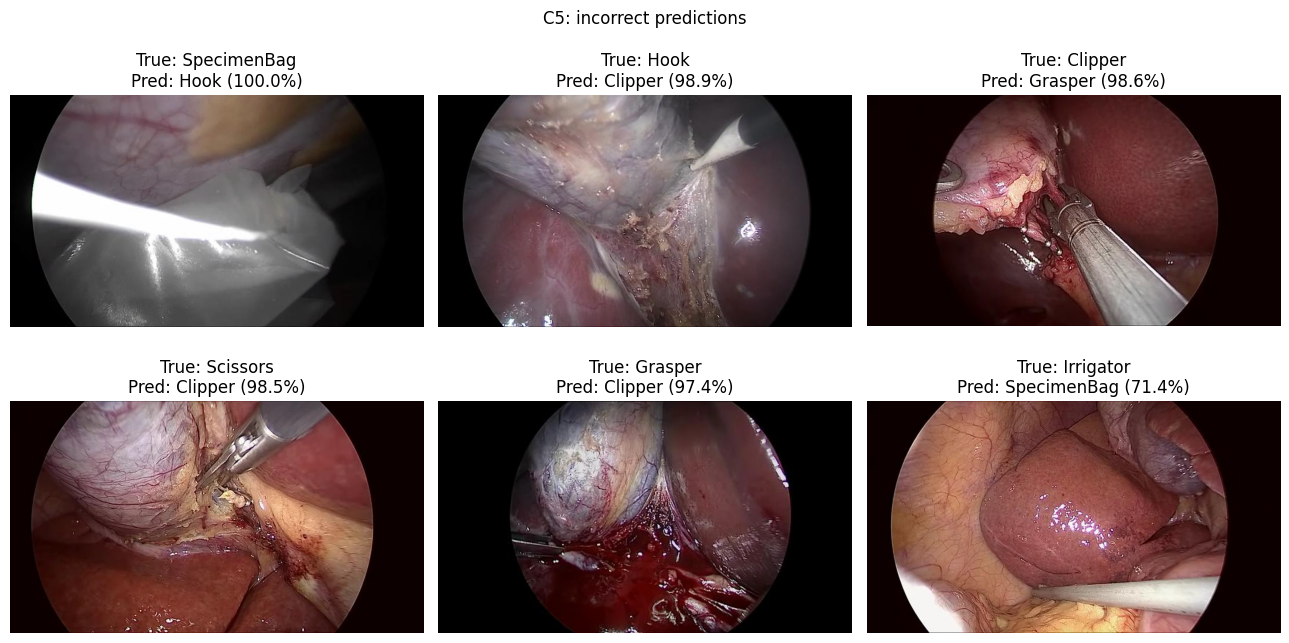

Task 1 analysis files saved to: /content/drive/MyDrive/BN5211/weights/task1_analysis


In [ ]:
##############################################################################
# TODO: Create the Task 1 figures and numerical summaries required by the
# Analysis Report, including but not limited to:
# - training/validation loss and accuracy across configurations;
# - a numerical table for the four controlled comparisons;
# - class-level evaluation of the selected final model;
# - representative correct and incorrect predictions.
# You may add additional cells as needed.
##############################################################################

import csv
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

analysis_dir = os.path.join(weights_root, 'task1_analysis')
os.makedirs(analysis_dir, exist_ok=True)
class_names = ['Bipolar', 'Clipper', 'Grasper', 'Hook',
               'Irrigator', 'Scissors', 'SpecimenBag']

# Display all six learning histories using consistent axes.
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for ax, (config_id, history) in zip(axes.flat, task1_histories.items()):
    epoch_axis = np.arange(1, len(history['train_loss']) + 1)
    ax.plot(epoch_axis, history['train_loss'], label='Training')
    ax.plot(epoch_axis, history['val_loss'], label='Validation')
    ax.set_title(config_id)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir, 'all_loss_curves.png'), dpi=200)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, (config_id, history) in zip(axes.flat, task1_histories.items()):
    epoch_axis = np.arange(1, len(history['train_accuracy']) + 1)
    ax.plot(epoch_axis, history['train_accuracy'], label='Training')
    ax.plot(epoch_axis, history['val_accuracy'], label='Validation')
    ax.set_title(config_id)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir, 'all_accuracy_curves.png'), dpi=200)
plt.show()

# Save and show checkpoint-level values and the four controlled comparisons.
def save_task1_table(rows, filename):
    with open(os.path.join(analysis_dir, filename), 'w', newline='',
              encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    columns = list(rows[0])
    print(' | '.join(columns))
    for row in rows:
        print(' | '.join(f'{row[key]:.4f}' if isinstance(row[key], float)
                         else str(row[key]) for key in columns))

save_task1_table(validation_summary, 'validation_summary.csv')
validation_by_id = {row['configuration']: row for row in validation_summary}
comparison_rows = []
for factor, first, second in [
    ('Architecture', 'C0', 'C1'), ('Optimizer', 'C1', 'C2'),
    ('Batch size', 'C2', 'C3'), ('Initialization', 'C4', 'C5'),
]:
    before = validation_by_id[first]
    after = validation_by_id[second]
    comparison_rows.append({
        'factor': factor, 'comparison': f'{first} -> {second}',
        'before_val_accuracy': before['val_accuracy'],
        'after_val_accuracy': after['val_accuracy'],
        'accuracy_change_percentage_points':
            100 * (after['val_accuracy'] - before['val_accuracy']),
        'val_loss_change': after['val_loss'] - before['val_loss'],
    })
save_task1_table(comparison_rows, 'controlled_comparisons.csv')

# Reuse the one saved test evaluation for all class-level analyses.
y_true = task1_test_results['labels']
y_pred = task1_test_results['predictions']
y_prob = task1_test_results['probabilities']
report = classification_report(y_true, y_pred, labels=list(range(7)),
                               target_names=class_names, zero_division=0,
                               output_dict=True)
print(classification_report(y_true, y_pred, labels=list(range(7)),
                            target_names=class_names, zero_division=0,
                            digits=4))
with open(os.path.join(analysis_dir, 'test_classification_report.json'),
          'w', encoding='utf-8') as file:
    json.dump(report, file, indent=2)

cm = confusion_matrix(y_true, y_pred, labels=list(range(7)))
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False,
)
ax.set_title(f'{selected_configuration}: final test confusion matrix')
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir, 'test_confusion_matrix.png'), dpi=200)
plt.show()

# Use the paths saved alongside predictions, even if file discovery order changes.
test_image_paths = task1_test_results['image_paths']
assert len(y_true) == len(test_image_paths)
prediction_rows = []
for index, path in enumerate(test_image_paths):
    prediction_rows.append({
        'image_path': path, 'true_class': class_names[int(y_true[index])],
        'predicted_class': class_names[int(y_pred[index])],
        'confidence': float(y_prob[index, y_pred[index]]),
        'correct': bool(y_true[index] == y_pred[index]),
    })
with open(os.path.join(analysis_dir, 'test_predictions.csv'), 'w',
          newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=list(prediction_rows[0]))
    writer.writeheader()
    writer.writerows(prediction_rows)

# Deterministic examples: one per true class first, then fill remaining slots.
# Wrong predictions are ranked by confidence to expose confident failures.
confidence = y_prob[np.arange(len(y_pred)), y_pred]
for correct_flag, title in [(True, 'Correct'), (False, 'Incorrect')]:
    candidates = np.flatnonzero((y_true == y_pred) == correct_flag)
    if len(candidates) == 0:
        print(f'No {title.lower()} test predictions to display.')
        continue
    ranked = candidates[np.argsort(-confidence[candidates], kind='stable')]
    selected_indices = []
    seen_classes = set()
    for index in ranked:
        if int(y_true[index]) not in seen_classes:
            selected_indices.append(int(index))
            seen_classes.add(int(y_true[index]))
        if len(selected_indices) == 6:
            break
    for index in ranked:
        if len(selected_indices) == 6:
            break
        if int(index) not in selected_indices:
            selected_indices.append(int(index))
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for ax in axes.flat:
        ax.axis('off')
    for ax, index in zip(axes.flat, selected_indices):
        with Image.open(test_image_paths[index]) as image:
            ax.imshow(image.convert('RGB'))
        ax.set_title(f'True: {class_names[int(y_true[index])]}\n'
                     f'Pred: {class_names[int(y_pred[index])]} '
                     f'({confidence[index]:.1%})')
    fig.suptitle(f'{selected_configuration}: {title.lower()} predictions')
    fig.tight_layout()
    fig.savefig(os.path.join(analysis_dir, f'{title.lower()}_examples.png'),
                dpi=200, bbox_inches='tight')
    plt.show()
print('Task 1 analysis files saved to:', analysis_dir)

##############################################################################
#                         END OF YOUR CODE
##############################################################################


### **[20%] Task 1 - Analysis Report**

Please present the following analysis in the separate PDF report. The code used to generate every reported figure and numerical result should remain in your submitted notebook, no need to show the code in the report.

- **A1.1 - Model-design explanation [2%]:** Briefly explain the implemented CNN architecture and the roles of its main components.

- **A1.2 - Training process and learning dynamics [6%]:** Use your visualizations to explain how training and validation performance change across epochs. Discuss convergence speed, stability, and any evidence of underfitting or overfitting.

- **A1.3 - Comparison analysis [6%]:** Compare the effects of architecture, optimizer, batch size, and ImageNet pretraining using validation results. Report the size of each performance change and discuss plausible reasons for what you observe.

- **A1.4 - Model selection and failure analysis [6%]:** Explain why you selected the final model, then report its test-set evaluation. Examine its class-level performance and representative correct and incorrect predictions, and discuss any recurring failure patterns you notice.

## Task 2: Surgical Action Recognition [25%]

In this task, you will move from instrument classification to action recognition in surgical images. The goal is to recognize fine-grained surgical actions (e.g., “picking up the needle”, “knot tying”) from individual frames sampled from a long procedure. Unlike instrument classification, action recognition is more challenging because a single frame may be visually ambiguous, and distinguishing between actions requires robust spatial feature extraction. This setting introduces challenges such as visual occlusions, class imbalance, and the high similarity between different actions.

We will start from a simple, strong baseline and train it end-to-end: **ResNet → Classifier**. As illustrated in the figure, the pipeline (i) takes a single frame as input, (ii) extracts features with a ResNet18 backbone (with pretrained ImageNet weights), and (iii) outputs an action label for frame-level prediction.

Task 2 consists of **Code Implementation [13%]** and **Analysis Report [12%]**. You will create your own visualizations in the indicated notebook cells.


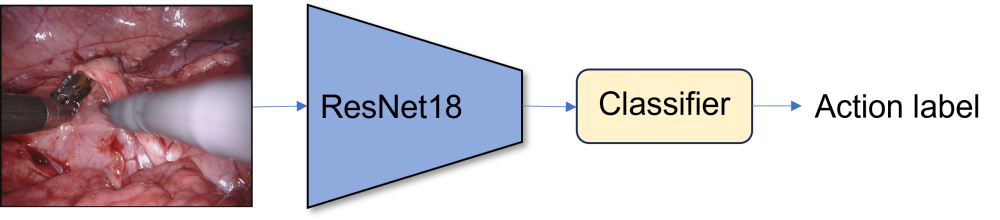

### **[5%] Q2.1: Implement the action-recognition dataset**

The dataset is organized by surgical sequence. Each sequence has an image folder and a corresponding annotation file containing comma-separated rows in the format:

```text
start_frame,end_frame,class_id
```

Both range endpoints are inclusive. For example, `120,184,3` assigns class 3 to frames 120 through 184.

Complete `RARPReader` and `RARPDataset` so that they:

- discover and sort valid image files;
- load the annotated frame ranges;
- obtain the frame ID from the image filename and assign the correct label;
- resize images to `(256, 512)` and normalize them using ImageNet mean and standard deviation;
- apply mild spatial and/or photometric augmentation only to the training split;
- concatenate all sequence readers within a split.

Each sample should return `(image_tensor, label, image_path)`. The image path will be useful later when you examine prediction errors.

In [ ]:
# Imports required for Task 2
# Uncomment the next line if torchinfo is not already installed.
# !pip install -q torchinfo

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.utils.data.dataset as Dataset
import torchvision

from PIL import Image
from sklearn.metrics import f1_score
from torch.utils.data import ConcatDataset
from torchinfo import summary
from torchvision.models import resnet18, ResNet18_Weights

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)


Using device: cuda:0


In [ ]:
class RARPReader(data.Dataset):
  """Read individual frames and action labels from one sequence."""

  def __init__(self, seq_image_dir, seq_action_path,
               resize_hw=(256, 512), is_train=True):
    self.seq_image_dir = seq_image_dir
    self.seq_action_path = seq_action_path
    self.is_train = is_train
    self.img_list = []
    for root, dirs,files in os.walk(seq_image_dir):
        for file in files:
            self.img_list.append(os.path.join(root, file))
    self.img_list = sorted(self.img_list)
    self.label_ranges = self.load_ranges(seq_action_path)

    ##############################################################################
    # TODO: Define the resize, training augmentation, and normalization.
    # Requirements:
    # - Resize every image to resize_hw.
    # - Convert the PIL image to a tensor.
    # - Normalize using ImageNet mean/std
    # - If is_train=True, you should at least add mild spatial augmentations
    #   (e.g., ColorJitter)
    ###############################################################################

    # Filter the template's file listing before deriving frame IDs.
    extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    self.img_list = [path for path in self.img_list
                     if os.path.splitext(path)[1].lower() in extensions
                     and os.path.splitext(os.path.basename(path))[0].isdigit()]
    self.img_list.sort(key=lambda path: (
        int(os.path.splitext(os.path.basename(path))[0]), path))
    if not self.img_list:
      raise ValueError(f'No numbered image files found in {seq_image_dir}')

    self.resize = torchvision.transforms.Resize(resize_hw)
    self.augmentation = torchvision.transforms.Compose([
        torchvision.transforms.RandomRotation(degrees=5),
        torchvision.transforms.ColorJitter(brightness=0.1, contrast=0.1,
                                           saturation=0.1, hue=0.02),
    ])
    self.image_transforms = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225]),
    ])
    # Validate every sampled frame once; also supports class-count analysis
    # without decoding images or applying random augmentation.
    self.targets = [self.get_label(
        int(os.path.splitext(os.path.basename(path))[0]), self.label_ranges,
    ) for path in self.img_list]

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################

  def load_ranges(self, txt_path):
    ##############################################################################
    # TODO: Read all non-empty annotation rows.
    # Each row has: start_frame,end_frame,class_id
    # Convert the values to integers and return a list of tuples:
    # [(start_frame, end_frame, class_id), ...]
    ##############################################################################

    ranges = []
    with open(txt_path, 'r', encoding='utf-8-sig') as file:
      for line_number, line in enumerate(file, start=1):
        if not line.strip():
          continue
        fields = line.strip().split(',')
        if len(fields) != 3:
          raise ValueError(f'{txt_path}:{line_number}: expected three values')
        start, end, class_id = map(int, fields)
        if start < 0 or end < start or not 0 <= class_id < 8:
          raise ValueError(f'{txt_path}:{line_number}: invalid annotation')
        ranges.append((start, end, class_id))
    ranges.sort(key=lambda row: (row[0], row[1]))
    if not ranges:
      raise ValueError(f'No annotations found in {txt_path}')
    for previous, current in zip(ranges, ranges[1:]):
      if current[0] <= previous[1]:
        raise ValueError(f'Overlapping inclusive ranges in {txt_path}')

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################
    return ranges


  def get_label(self, frame_id, ranges):
    ##############################################################################
    # TODO: Return the class ID whose inclusive range contains frame_id.
    ##############################################################################

    for start, end, class_id in ranges:
      if start <= frame_id <= end:
        return class_id
    raise ValueError(f'Frame {frame_id} has no label in {self.seq_action_path}')

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, sample_idx):
    ##############################################################################
    # TODO: Load and transform one frame.
    # - Obtain frame_id from the integer filename stem; for example,
    #   00001.jpg corresponds to frame_id=1.
    # - Open the sampled image, convert to RGB, resize to (256, 512) and apply transforms
    # - If it is training, apply augmentation
    # - Return (image_tensor, label, image_path).
    ###############################################################################

    image_path = self.img_list[sample_idx]
    label = self.targets[sample_idx]
    with Image.open(image_path) as source:
      image = self.resize(source.convert('RGB'))
    if self.is_train:
      image = self.augmentation(image)
    image_tensor = self.image_transforms(image)

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################
    return image_tensor, label, image_path


class RARPDataset(Dataset.Dataset):
  # NOTE:
  # Action classes:
  # 0 -> Other
  # 1 -> Picking up the needle
  # 2 -> Positioning the needle tip
  # 3 -> Pushing the needle through the tissue
  # 4 -> Pulling the needle out of the tissue
  # 5 -> Tying a knot
  # 6 -> Cutting the suture
  # 7 -> Returning/dropping the needle

  def __init__(self, dataset_root, resize_hw=(256, 512), is_train=True):
    self.dataset_root = dataset_root
    self.is_train = is_train
    self.sub_readers = []

    image_root = os.path.join(dataset_root, 'images')
    action_root = os.path.join(dataset_root, 'actions')

    # ##############################################################################
    # TODO: Use RARPReader to load each sequence
    # - Instantiate a RARPReader with the given image directory and action file
    # - Append the RARPReader object to self.sub_readers
    # ##############################################################################

    if not os.path.isdir(image_root) or not os.path.isdir(action_root):
      raise FileNotFoundError(f'Missing images/actions folders in {dataset_root}')
    for sequence in sorted(os.listdir(image_root)):
      seq_image_dir = os.path.join(image_root, sequence)
      if not os.path.isdir(seq_image_dir):
        continue
      seq_action_path = os.path.join(action_root, sequence + '.txt')
      if not os.path.isfile(seq_action_path):
        raise FileNotFoundError(f'Missing annotation: {seq_action_path}')
      self.sub_readers.append(RARPReader(
          seq_image_dir, seq_action_path, resize_hw=resize_hw,
          is_train=is_train,
      ))
    if not self.sub_readers:
      raise ValueError(f'No surgical sequences found in {image_root}')
    self.targets = [label for reader in self.sub_readers
                    for label in reader.targets]
    self.image_paths = [path for reader in self.sub_readers
                        for path in reader.img_list]

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################

    # Concat all the sub-readers
    self.dataset = ConcatDataset(self.sub_readers)

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, index):
    return self.dataset[index]


### **[4%] Q2.2: Implement the frame-level ResNet18 classifier**

Build a frame-level action classifier using an ImageNet-pretrained ResNet18. Keep the ResNet18 feature extractor and global average pooling, then replace the original ImageNet classifier with an eight-class linear layer.

This task uses one frame per prediction; there is no temporal dimension or temporal averaging in the model.


In [ ]:
# build the model with pretrained ResNet18
class RARPResnet(nn.Module):
  def __init__(self, num_classes=8):
    super(RARPResnet, self).__init__()
    self.num_classes = num_classes
    ##############################################################################
    # TODO: Define the frame-level classifier.
    # Requirements:
    # - Backbone: build a ResNet18 feature extractor from torchvision with
    #   pretrained weights. Remove the final fully connected layer (keep avgpool).
    # - Classifier: a Linear head mapping d_model -> num_classes.
    ##############################################################################

    network = resnet18(weights=ResNet18_Weights.DEFAULT)
    feature_dim = network.fc.in_features
    # Retain all convolutional stages and the global average-pooling layer.
    self.backbone = nn.Sequential(*list(network.children())[:-1])
    self.classifier = nn.Linear(feature_dim, num_classes)

    # ##############################################################################
    #              END OF YOUR CODE
    # ##############################################################################

  def forward(self, x):
    ##############################################################################
    # TODO: Implement the frame-level forward pass.
    # - Input: x with shape (B, 3, H, W).
    # - Extract one feature vector for each frame.
    # - Apply the classifier and return logits with shape (B, num_classes).
    ##############################################################################

    features = self.backbone(x)
    features = torch.flatten(features, start_dim=1)
    logits = self.classifier(features)

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################
    return logits

### **[4%] Q2.3: Implement training and evaluation**

Complete the evaluation and training functions below. Use validation performance to select the best checkpoint. After training is complete, load that checkpoint and evaluate on the test set.


In [ ]:
@torch.inference_mode()
def rarp_evaluate(model, loader, criterion, device):
  ##############################################################################
  # TODO: Evaluate the action-recognition model.
  # Requirements:
  # - Use model.eval() and do not compute gradients.
  # - Compute average loss and accuracy in [0, 1].
  # - Compute suitable metrics for reporting model performance of your choices (for later analysis)
  # - Collect ground-truth labels, predictions, probabilities, and paths.
  # - Return results in a suitable format that can be used for analysis and reporting.
  ##############################################################################

  model.eval()
  total_loss = 0.0
  sample_count = 0
  all_labels, all_predictions, all_probabilities, all_paths = [], [], [], []

  for images, labels, paths in loader:
    images = images.to(device)
    labels = labels.to(device)
    logits = model(images)
    loss = criterion(logits, labels)
    batch_count = labels.size(0)
    # The supplied criterion is unweighted mean CrossEntropyLoss.
    total_loss += loss.item() * batch_count
    sample_count += batch_count
    all_labels.append(labels.cpu())
    all_predictions.append(logits.argmax(dim=1).cpu())
    all_probabilities.append(torch.softmax(logits, dim=1).cpu())
    all_paths.extend(paths)

  if sample_count == 0:
    raise ValueError('The evaluation loader contains no frames.')
  labels = torch.cat(all_labels).numpy()
  predictions = torch.cat(all_predictions).numpy()
  probabilities = torch.cat(all_probabilities).numpy()
  class_ids = np.arange(probabilities.shape[1])
  per_class_f1 = f1_score(labels, predictions, labels=class_ids,
                          average=None, zero_division=0)
  support = np.bincount(labels, minlength=len(class_ids))
  return {
      'loss': total_loss / sample_count,
      'accuracy': float(np.mean(labels == predictions)),
      'micro_f1': float(f1_score(labels, predictions, labels=class_ids,
                                  average='micro', zero_division=0)),
      # Main macro-F1 always averages over all eight task classes.
      # Absent classes receive zero; the supported-class mean is supplemental.
      'macro_f1': float(per_class_f1.mean()),
      'weighted_f1': float(f1_score(labels, predictions, labels=class_ids,
                                     average='weighted', zero_division=0)),
      'macro_f1_supported': float(per_class_f1[support > 0].mean()),
      'class_support': support,
      'class_f1': per_class_f1,
      'labels': labels,
      'predictions': predictions,
      'probabilities': probabilities,
      'paths': np.asarray(all_paths, dtype=str),
  }

  ##############################################################################
  #                         END OF YOUR CODE
  ##############################################################################

In [ ]:
def rarp_training(model, train_loader, val_loader, optimizer, scheduler,
                  criterion, num_epochs, weights_root, device):
  ##############################################################################
  # TODO: Train and validate the action-recognition model.
  # Requirements:
  # - Complete the standard training steps for every batch.
  # - Evaluate on the validation set at periodically.
  # - Record training loss and suitable metrics for validation.
  # - Save two models:
  # (1) rarp_model_best.pth for the best validation performance;
  # (2) rarp_model.pth for the final epoch.
  # - Step the scheduler once per epoch.
  # - Return a history dictionary containing all recorded metrics.
  # - Do not access the test set and do not generate plots here.
  ##############################################################################

  import json

  if num_epochs < 1:
    raise ValueError('num_epochs must be at least one.')
  os.makedirs(weights_root, exist_ok=True)
  best_path = os.path.join(weights_root, 'rarp_model_best.pth')
  final_path = os.path.join(weights_root, 'rarp_model.pth')
  history_path = os.path.join(weights_root, 'task2_history.json')
  selection_path = os.path.join(weights_root, 'task2_best_validation.json')
  history = {key: [] for key in [
      'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy',
      'val_micro_f1', 'val_macro_f1', 'val_weighted_f1',
      'val_macro_f1_supported', 'learning_rate',
  ]}
  # Prioritize minority-class performance; use accuracy and loss to break ties.
  best_score = (-float('inf'), -float('inf'), -float('inf'))
  for epoch in range(num_epochs):
    model.train()
    total_loss, total_correct, sample_count = 0.0, 0, 0
    epoch_lr = float(optimizer.param_groups[0]['lr'])
    for images, labels, _ in train_loader:
      images = images.to(device)
      labels = labels.to(device)
      optimizer.zero_grad()
      logits = model(images)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()
      batch_count = labels.size(0)
      total_loss += loss.item() * batch_count
      total_correct += (logits.argmax(dim=1) == labels).sum().item()
      sample_count += batch_count
    if sample_count == 0:
      raise ValueError('The training loader contains no frames.')

    val_results = rarp_evaluate(model, val_loader, criterion, device)
    history['train_loss'].append(total_loss / sample_count)
    history['train_accuracy'].append(total_correct / sample_count)
    history['learning_rate'].append(epoch_lr)
    for metric in ['loss', 'accuracy', 'micro_f1', 'macro_f1',
                   'weighted_f1', 'macro_f1_supported']:
      history['val_' + metric].append(val_results[metric])

    score = (val_results['macro_f1'], val_results['accuracy'],
             -val_results['loss'])
    if score > best_score:
      best_score = score
      # CPU state dictionaries can be loaded on GPU or CPU later.
      torch.save({key: value.detach().cpu()
                  for key, value in model.state_dict().items()}, best_path)
      selection = {
          'best_epoch': epoch + 1,
          'selection_rule': 'max macro-F1 (all 8 classes), then accuracy, '
                            'then min loss; retain earliest exact tie',
          'val_loss': val_results['loss'],
          'val_accuracy': val_results['accuracy'],
          'val_macro_f1': val_results['macro_f1'],
          'val_macro_f1_supported': val_results['macro_f1_supported'],
      }
      with open(selection_path, 'w', encoding='utf-8') as file:
        json.dump(selection, file, indent=2)

    scheduler.step()
    # Persist history every epoch, including progress before a disconnection.
    with open(history_path, 'w', encoding='utf-8') as file:
      json.dump(history, file, indent=2)
    print(f'Epoch {epoch + 1:02d}/{num_epochs} | lr={epoch_lr:.6g} | '
          f"train loss={history['train_loss'][-1]:.4f}, "
          f"acc={history['train_accuracy'][-1]:.4f} | "
          f"val loss={val_results['loss']:.4f}, "
          f"acc={val_results['accuracy']:.4f}, "
          f"macro-F1={val_results['macro_f1']:.4f}")

  torch.save({key: value.detach().cpu()
              for key, value in model.state_dict().items()}, final_path)
  return history

  ##############################################################################
  #                         END OF YOUR CODE
  ##############################################################################

In [ ]:
# Starting hyperparameters. You may adjust them using validation results
num_epochs = 20
batch_size = 16
learning_rate = 0.0005
step_size = 8
num_classes = 8

In [ ]:
# Prepare Task 2 datasets and dataloaders.
weights_root_task2 = os.path.join(drive_root, 'weights')
dataset_root_task2 = os.path.join(drive_root, 'RARP_1FPS')

path_train_task2 = os.path.join(dataset_root_task2, 'train')
path_val_task2 = os.path.join(dataset_root_task2, 'val')
path_test_task2 = os.path.join(dataset_root_task2, 'test')

dataset_train_task2 = RARPDataset(
  path_train_task2, resize_hw=(256, 512), is_train=True
)
dataset_val_task2 = RARPDataset(
  path_val_task2, resize_hw=(256, 512), is_train=False
)
dataset_test_task2 = RARPDataset(
  path_test_task2, resize_hw=(256, 512), is_train=False
)

train_loader_task2 = torch.utils.data.DataLoader(
  dataset_train_task2, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader_task2 = torch.utils.data.DataLoader(
  dataset_val_task2, batch_size=batch_size, shuffle=False, num_workers=2
)
test_loader_task2 = torch.utils.data.DataLoader(
  dataset_test_task2, batch_size=batch_size, shuffle=False, num_workers=2
)


In [ ]:
# Instantiate the model and move it to the appropriate device
model_task2 = RARPResnet(num_classes=num_classes).to(device)

# Print the model architecture
summary(
  model_task2,
  input_size=(1, 3, 256, 512),
  col_names=('input_size', 'output_size', 'num_params'),
  depth=3,
)

# Use Adam optimizer
optimizer_task2 = optim.Adam(model_task2.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler_task2 = optim.lr_scheduler.StepLR(
  optimizer_task2, step_size=step_size, gamma=0.5
)

criterion_task2 = nn.CrossEntropyLoss().to(device)

In [ ]:
##############################################################################
# TODO: Train the Task 2 model by calling rarp_training with the required
# arguments. Store the returned history for the Analysis Report.
##############################################################################

history_task2 = rarp_training(
    model_task2, train_loader_task2, val_loader_task2,
    optimizer_task2, scheduler_task2, criterion_task2,
    num_epochs, weights_root_task2, device,
)
print('Best checkpoint:', os.path.join(weights_root_task2, 'rarp_model_best.pth'))
print('Final checkpoint:', os.path.join(weights_root_task2, 'rarp_model.pth'))

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Epoch 01/20 | lr=0.0005 | train loss=0.8483, acc=0.6972 | val loss=1.8803, acc=0.4721, macro-F1=0.1985
Epoch 02/20 | lr=0.0005 | train loss=0.6539, acc=0.7671 | val loss=2.5270, acc=0.2575, macro-F1=0.1796
Epoch 03/20 | lr=0.0005 | train loss=0.4901, acc=0.8313 | val loss=2.6530, acc=0.4249, macro-F1=0.1692
Epoch 04/20 | lr=0.0005 | train loss=0.3969, acc=0.8628 | val loss=1.6323, acc=0.4549, macro-F1=0.2448
Epoch 05/20 | lr=0.0005 | train loss=0.2757, acc=0.9079 | val loss=1.8167, acc=0.5150, macro-F1=0.3183
Epoch 06/20 | lr=0.0005 | train loss=0.2494, acc=0.9141 | val loss=2.1360, acc=0.4034, macro-F1=0.2337
Epoch 07/20 | lr=0.0005 | train loss=0.1690, acc=0.9477 | val loss=1.8475, acc=0.4378, macro-F1=0.1968
Epoch 08/20 | lr=0.00025 | train loss=0.0895, acc=0.9710 | val loss=2.0513, acc=0.4850, macro-F1=0.2530
Epoch 09/20 | lr=0.00025 | train loss=0.0350, acc=0.9938 | val loss=1.7531, acc=0.4850, macro-F1=0.2495
Epoch 10/20 | lr=0.00025 | train loss=0.0201, acc=0.9969 | val loss=1.7

In [ ]:
##############################################################################
# TODO: Load rarp_model_best.pth and evaluate it on test_loader_task2
# Store the returned labels, predictions, probabilities, and
# paths for the class-level and failure analyses in Q2.4.
############################################################################

import json
import hashlib

best_path_task2 = os.path.join(weights_root_task2, 'rarp_model_best.pth')
model_task2.load_state_dict(torch.load(best_path_task2, map_location=device,
                                      weights_only=True))
model_task2.eval()
with open(os.path.join(weights_root_task2, 'task2_best_validation.json'),
          encoding='utf-8') as file:
    best_validation_task2 = json.load(file)
print('Checkpoint selected using validation data:', best_validation_task2)

# Save the chosen checkpoint's identity before evaluating held-out frames.
hasher = hashlib.sha256()
with open(best_path_task2, 'rb') as file:
    for chunk in iter(lambda: file.read(1024 * 1024), b''):
        hasher.update(chunk)
selection_task2 = {
    'checkpoint_sha256': hasher.hexdigest(),
    'best_validation': best_validation_task2,
    'test_paths': dataset_test_task2.image_paths,
}
selection_path_task2 = os.path.join(weights_root_task2, 'task2_final_selection.json')
results_path_task2 = os.path.join(weights_root_task2, 'task2_test_results.npz')
if os.path.exists(selection_path_task2):
    with open(selection_path_task2, encoding='utf-8') as file:
        previous_selection_task2 = json.load(file)
    if previous_selection_task2 != selection_task2:
        raise RuntimeError('Final Task 2 selection is already recorded. Do not '
                           'change the chosen checkpoint after viewing test results.')
if os.path.exists(results_path_task2) and not os.path.exists(selection_path_task2):
    raise RuntimeError('Saved test results are missing their selection record.')
with open(selection_path_task2, 'w', encoding='utf-8') as file:
    json.dump(selection_task2, file, indent=2)
if os.path.exists(results_path_task2):
    with np.load(results_path_task2, allow_pickle=False) as saved:
        results_task2 = {key: saved[key].copy() for key in saved.files}
    for metric in ['loss', 'accuracy', 'micro_f1', 'macro_f1',
                   'weighted_f1', 'macro_f1_supported']:
        results_task2[metric] = float(results_task2[metric])
    print('Reusing saved test predictions; no repeat test evaluation.')
else:
    results_task2 = rarp_evaluate(model_task2, test_loader_task2,
                                 criterion_task2, device)
    np.savez_compressed(results_path_task2, **results_task2)
for metric in ['loss', 'accuracy', 'micro_f1', 'macro_f1',
               'weighted_f1', 'macro_f1_supported']:
    print(f"Test {metric}: {results_task2[metric]:.4f}")
print('Macro-F1 uses all 8 classes with zero_division=0. '
      'macro_f1_supported averages only classes with true samples.')

##############################################################################
#                         END OF YOUR CODE
##############################################################################


Checkpoint selected using validation data: {'best_epoch': 18, 'selection_rule': 'max macro-F1 (all 8 classes), then accuracy, then min loss; retain earliest exact tie', 'val_loss': 1.8269976101208143, 'val_accuracy': 0.6051502145922747, 'val_macro_f1': 0.3691495824485947, 'val_macro_f1_supported': 0.4218852370841083}
Test loss: 1.1660
Test accuracy: 0.6982
Test micro_f1: 0.6982
Test macro_f1: 0.4374
Test weighted_f1: 0.6870
Test macro_f1_supported: 0.4999
Macro-F1 uses all 8 classes with zero_division=0. macro_f1_supported averages only classes with true samples.


#### Prepare your Task 2 results

Use the cell below to create the figures and numerical summaries needed for Q2.4. You may choose any clear and appropriate visualization style and add more cells if needed.


class_id | action | train | val | test
0 | Other | 260 | 13 | 90
1 | Picking up the needle | 103 | 12 | 13
2 | Positioning the needle tip | 473 | 53 | 125
3 | Pushing the needle through the tissue | 521 | 76 | 119
4 | Pulling the needle out of the tissue | 418 | 60 | 82
5 | Tying a knot | 47 | 0 | 0
6 | Cutting the suture | 43 | 5 | 5
7 | Returning/dropping the needle | 67 | 14 | 20


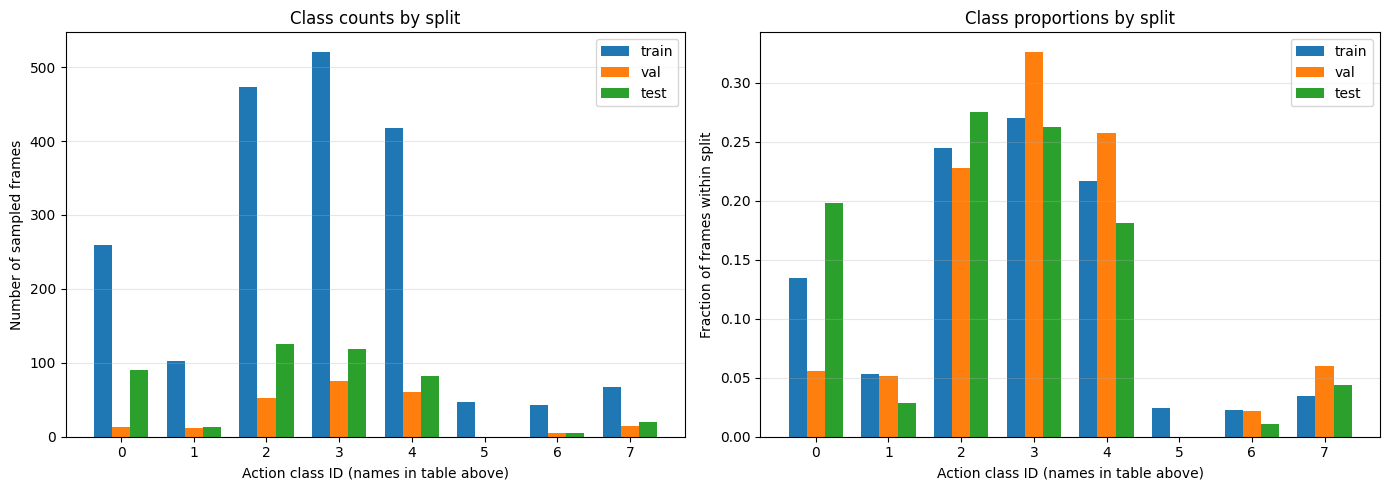

val: no true samples for ['Tying a knot']; recall for these classes cannot be estimated from this split.
test: no true samples for ['Tying a knot']; recall for these classes cannot be estimated from this split.


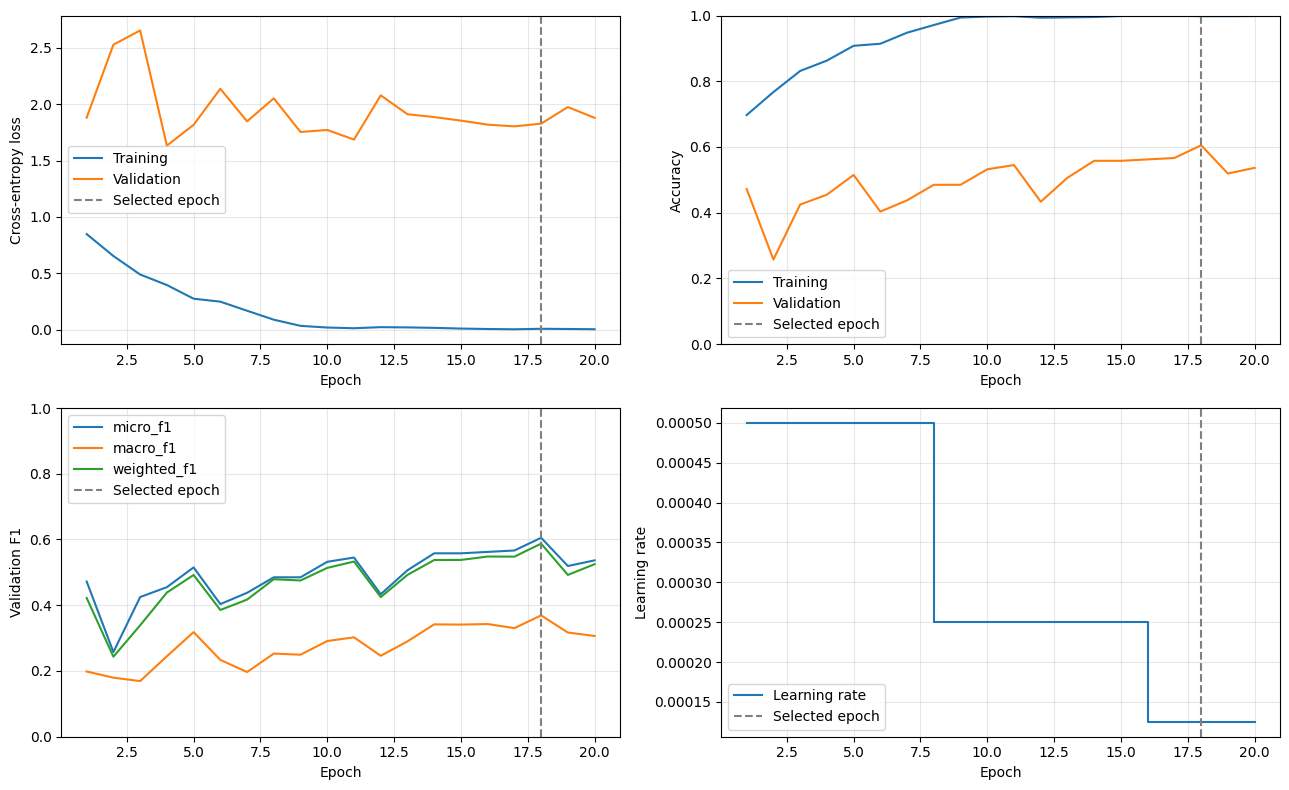

Best validation checkpoint: {'best_epoch': 18, 'selection_rule': 'max macro-F1 (all 8 classes), then accuracy, then min loss; retain earliest exact tie', 'val_loss': 1.8269976101208143, 'val_accuracy': 0.6051502145922747, 'val_macro_f1': 0.3691495824485947, 'val_macro_f1_supported': 0.4218852370841083}
metric | value
loss | 1.1660
accuracy | 0.6982
micro_f1 | 0.6982
macro_f1 | 0.4374
weighted_f1 | 0.6870
macro_f1_supported | 0.4999
In single-label multiclass classification, micro-F1 equals accuracy. Macro-F1 weights each class equally; weighted-F1 uses class support. Here macro-F1 fixes all 8 labels and uses zero_division=0; the supported-class macro-F1 is also reported explicitly.
                                       precision    recall  f1-score   support

                                Other     0.7345    0.9222    0.8177        90
                Picking up the needle     1.0000    0.1538    0.2667        13
           Positioning the needle tip     0.7073    0.6960    0.7016   

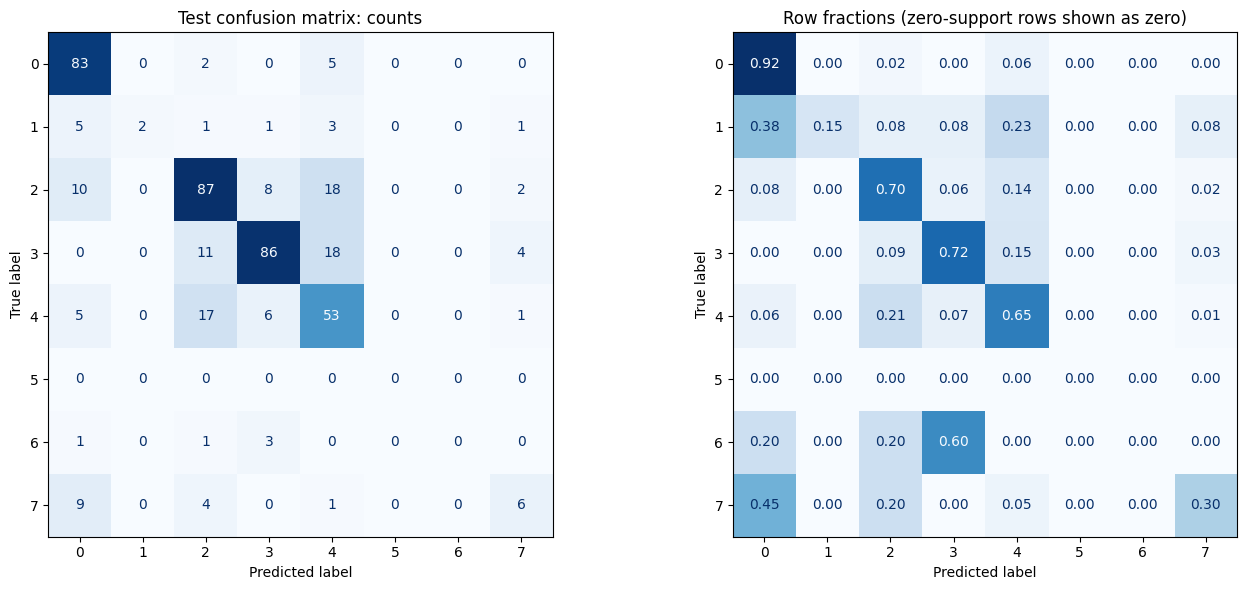

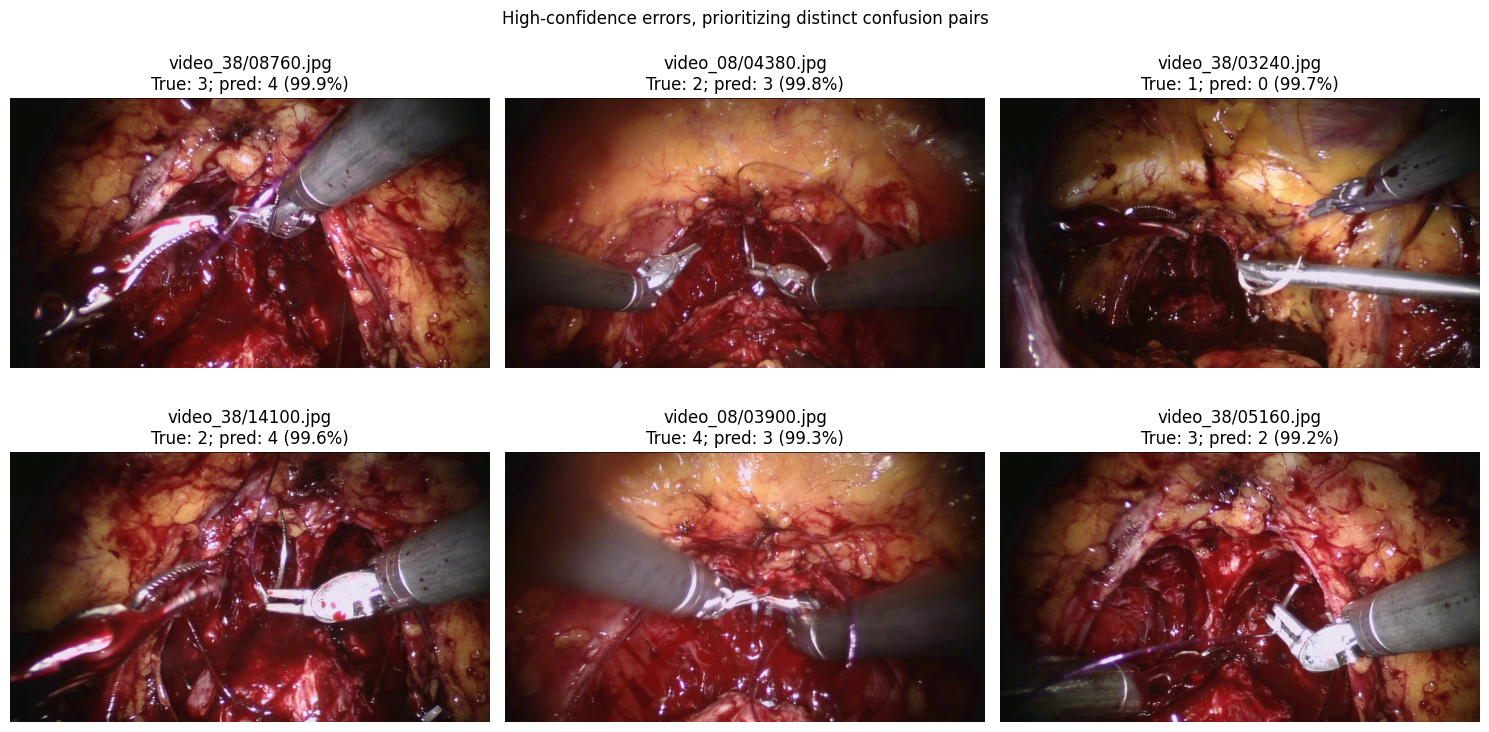

Task 2 analysis files saved to: /content/drive/MyDrive/BN5211/weights/task2_analysis


In [ ]:
##############################################################################
# TODO: Create the Task 2 figures and numerical summaries required by Analysis Report
# You may add additional cells as needed.
##############################################################################

import csv
import json
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

analysis_dir_task2 = os.path.join(weights_root_task2, 'task2_analysis')
os.makedirs(analysis_dir_task2, exist_ok=True)
action_names = [
    'Other', 'Picking up the needle', 'Positioning the needle tip',
    'Pushing the needle through the tissue',
    'Pulling the needle out of the tissue', 'Tying a knot',
    'Cutting the suture', 'Returning/dropping the needle',
]
action_ids = np.arange(8)

def save_task2_table(rows, filename):
    with open(os.path.join(analysis_dir_task2, filename), 'w', newline='',
              encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    print(' | '.join(rows[0]))
    for row in rows:
        print(' | '.join(f'{value:.4f}' if isinstance(value, float) else str(value)
                         for value in row.values()))

# A2.1: Count sampled frames, not annotation intervals or original video frames.
counts_task2 = {}
for split, dataset in [('train', dataset_train_task2),
                       ('val', dataset_val_task2),
                       ('test', dataset_test_task2)]:
    counts_task2[split] = np.bincount(dataset.targets, minlength=8)
class_rows_task2 = [
    {'class_id': int(i), 'action': action_names[i],
     **{split: int(counts[i]) for split, counts in counts_task2.items()}}
    for i in action_ids
]
save_task2_table(class_rows_task2, 'class_distribution.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for offset, (split, counts) in enumerate(counts_task2.items()):
    positions = action_ids + (offset - 1) * 0.25
    axes[0].bar(positions, counts, width=0.25, label=split)
    axes[1].bar(positions, counts / counts.sum(), width=0.25, label=split)
for ax in axes:
    ax.set_xticks(action_ids)
    ax.set_xlabel('Action class ID (names in table above)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Number of sampled frames')
axes[0].set_title('Class counts by split')
axes[1].set_ylabel('Fraction of frames within split')
axes[1].set_title('Class proportions by split')
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task2, 'class_distribution.png'), dpi=200)
plt.show()
for split, counts in counts_task2.items():
    missing = [action_names[i] for i in action_ids if counts[i] == 0]
    if missing:
        print(f'{split}: no true samples for {missing}; recall for these '
              'classes cannot be estimated from this split.')

# A2.2: Learning curves and the checkpoint selected by validation macro-F1.
with open(os.path.join(weights_root_task2, 'task2_history.json'),
          encoding='utf-8') as file:
    history_task2 = json.load(file)
with open(os.path.join(weights_root_task2, 'task2_best_validation.json'),
          encoding='utf-8') as file:
    best_validation_task2 = json.load(file)
epoch_axis_task2 = np.arange(1, len(history_task2['train_loss']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(epoch_axis_task2, history_task2['train_loss'], label='Training')
axes[0, 0].plot(epoch_axis_task2, history_task2['val_loss'], label='Validation')
axes[0, 0].set_ylabel('Cross-entropy loss')
axes[0, 1].plot(epoch_axis_task2, history_task2['train_accuracy'], label='Training')
axes[0, 1].plot(epoch_axis_task2, history_task2['val_accuracy'], label='Validation')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0, 1)
for metric in ['micro_f1', 'macro_f1', 'weighted_f1']:
    axes[1, 0].plot(epoch_axis_task2, history_task2['val_' + metric], label=metric)
axes[1, 0].set_ylabel('Validation F1')
axes[1, 0].set_ylim(0, 1)
axes[1, 1].step(epoch_axis_task2, history_task2['learning_rate'], where='post',
                label='Learning rate')
axes[1, 1].set_ylabel('Learning rate')
for ax in axes.flat:
    ax.axvline(best_validation_task2['best_epoch'], color='gray', linestyle='--',
               label='Selected epoch')
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task2, 'learning_curves.png'), dpi=200)
plt.show()
print('Best validation checkpoint:', best_validation_task2)

# A2.3: All test analyses reuse the predictions stored in the previous cell.
y_true_task2 = results_task2['labels']
y_pred_task2 = results_task2['predictions']
y_prob_task2 = results_task2['probabilities']
paths_task2 = results_task2['paths']
metric_names_task2 = ['loss', 'accuracy', 'micro_f1', 'macro_f1',
                      'weighted_f1', 'macro_f1_supported']
save_task2_table([{'metric': name, 'value': float(results_task2[name])}
                  for name in metric_names_task2], 'test_metrics.csv')
print('In single-label multiclass classification, micro-F1 equals accuracy. '
      'Macro-F1 weights each class equally; weighted-F1 uses class support. '
      'Here macro-F1 fixes all 8 labels and uses zero_division=0; the '
      'supported-class macro-F1 is also reported explicitly.')
report_task2 = classification_report(
    y_true_task2, y_pred_task2, labels=action_ids,
    target_names=action_names, zero_division=0, output_dict=True,
)
print(classification_report(y_true_task2, y_pred_task2, labels=action_ids,
                            target_names=action_names, zero_division=0, digits=4))
with open(os.path.join(analysis_dir_task2, 'classification_report.json'),
          'w', encoding='utf-8') as file:
    json.dump(report_task2, file, indent=2)
per_class_rows = [
    {'class_id': int(i), 'action': name,
     'precision': float(report_task2[name]['precision']),
     'recall': float(report_task2[name]['recall']),
     'f1': float(report_task2[name]['f1-score']),
     'support': int(report_task2[name]['support'])}
    for i, name in enumerate(action_names)
]
save_task2_table(per_class_rows, 'per_class_metrics.csv')
supported_rows = [row for row in per_class_rows if row['support'] > 0]
best_f1 = max(row['f1'] for row in supported_rows)
worst_f1 = min(row['f1'] for row in supported_rows)
print('Best supported classes by F1:',
      [row['action'] for row in supported_rows if row['f1'] == best_f1])
print('Worst supported classes by F1:',
      [row['action'] for row in supported_rows if row['f1'] == worst_f1])

cm_task2 = confusion_matrix(y_true_task2, y_pred_task2, labels=action_ids)
support_task2 = cm_task2.sum(axis=1, keepdims=True)
normalized_cm_task2 = np.divide(cm_task2, support_task2,
                                out=np.zeros_like(cm_task2, dtype=float),
                                where=support_task2 != 0)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(cm_task2, display_labels=action_ids).plot(
    ax=axes[0], cmap='Blues', colorbar=False,
)
ConfusionMatrixDisplay(normalized_cm_task2, display_labels=action_ids).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f',
)
axes[0].set_title('Test confusion matrix: counts')
axes[1].set_title('Row fractions (zero-support rows shown as zero)')
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task2, 'confusion_matrices.png'), dpi=200)
plt.show()

# A2.4: Export each prediction and inspect high-confidence, diverse errors.
confidence_task2 = y_prob_task2[np.arange(len(y_pred_task2)), y_pred_task2]
prediction_rows_task2 = [
    {'image_path': str(path), 'true_class': int(y_true_task2[i]),
     'predicted_class': int(y_pred_task2[i]),
     'confidence': float(confidence_task2[i]),
     'correct': bool(y_true_task2[i] == y_pred_task2[i])}
    for i, path in enumerate(paths_task2)
]
with open(os.path.join(analysis_dir_task2, 'test_predictions.csv'), 'w',
          newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=list(prediction_rows_task2[0]))
    writer.writeheader()
    writer.writerows(prediction_rows_task2)
error_indices = np.flatnonzero(y_true_task2 != y_pred_task2)
if len(error_indices) == 0:
    print('No incorrect predictions in this test evaluation.')
else:
    ranked_errors = error_indices[np.argsort(-confidence_task2[error_indices],
                                             kind='stable')]
    chosen_errors, seen_pairs = [], set()
    for i in ranked_errors:
        pair = (int(y_true_task2[i]), int(y_pred_task2[i]))
        if pair not in seen_pairs:
            chosen_errors.append(int(i))
            seen_pairs.add(pair)
        if len(chosen_errors) == 6:
            break
    for i in ranked_errors:
        if len(chosen_errors) == 6:
            break
        if int(i) not in chosen_errors:
            chosen_errors.append(int(i))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax in axes.flat:
        ax.axis('off')
    for ax, i in zip(axes.flat, chosen_errors):
        with Image.open(paths_task2[i]) as image:
            ax.imshow(image.convert('RGB'))
        sequence = os.path.basename(os.path.dirname(paths_task2[i]))
        frame = os.path.basename(paths_task2[i])
        ax.set_title(f'{sequence}/{frame}\n'
                     f'True: {int(y_true_task2[i])}; pred: {int(y_pred_task2[i])} '
                     f'({confidence_task2[i]:.1%})')
    fig.suptitle('High-confidence errors, prioritizing distinct confusion pairs')
    fig.tight_layout()
    fig.savefig(os.path.join(analysis_dir_task2, 'incorrect_predictions.png'),
                dpi=200, bbox_inches='tight')
    plt.show()
print('Task 2 analysis files saved to:', analysis_dir_task2)

##############################################################################
#                         END OF YOUR CODE
##############################################################################


### **[12%] Task 2 - Analysis Report**

Please present the following analysis in the separate PDF report. Keep the code used to generate every figure and numerical result in your submitted notebook; the report only needs to show the resulting figures, values, and discussion.

- **A2.1 - Dataset and class-distribution analysis [3%]:** Report the number of frames in each action class and discuss how the distribution may affect model performance.

- **A2.2 - Training process and learning dynamics [3%]:** Use your own visualizations to discuss convergence, training stability, and any evidence of underfitting or overfitting.

- **A2.3 - Model performance analysis [3%]:** Report and interpret test accuracy, micro-F1, macro-F1, weighted-F1, and class-level performance. Discuss why these metrics may differ, identify the best- and worst-performing classes, and explain which metric gives the most informative view of performance for this dataset.

- **A2.4 - Failure and task-limitation analysis [3%]:** Visualize representative incorrect predictions and discuss possible causes.

## Task 3: Constrastive learning **[35%]**

In Task 1, we have trained the deep learning model by optimizing the nework with the guidance of label. However, the labeling work is timeconsuming and difficult to achieve accurate label in various tasks. The reliance on large scale data of deep learning models makes us need to think: How to use the unlabeled data to benefit optimization?

### The target of constrastive learning

To use unlabeled data to benefit model optimization, contrastive learning was born. It can realize the model optimization by large unlabeled data and few labeled data. The principle of contrastive learning is: Learn the same features among instances of the same class and distinguish differences between instances of the same class. The learning process does not require the label of each instance. It can provide a pre-trained model without labels for fine-tunning.


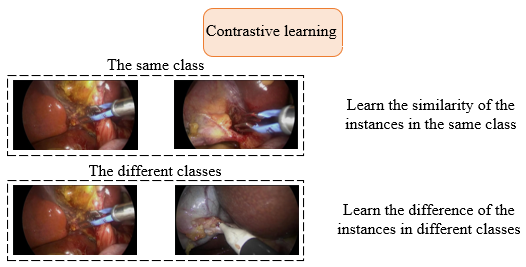

As shown in the following figure, the instances of different classes.

1. **For the positive pairs**: Because of the smilar regions (red box), the different instances of Bipolar are grouped into the same class. The backgroud regions are not important for the classification task. Hence, the distance between the two instances can be measured by the similarity calculation on the red box.
2. **For the negative pairs**: Because of the difference between Hook instance and Bipolar instance (red box), the two instances should be classified into different classes.

Hence, if a network could narrow the distance of instances in the same class and enlarge the distance of instance in the different class, this network can realize the classification without labels.

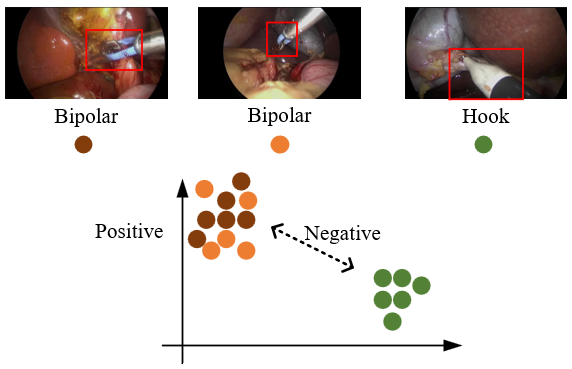

To make this ability available, contrastive learning constructs the positive and negative pairs to guide the network distingush each instance. Though comparing the similarity and difference, the network could understand the class of each instance.

There are lots of strategies in contrastive learning to realize this. Here, we conduct the strategy: guiding the network capture the similarity of instances in the same class by contrastive learning.

### Set a contrastive learning strategy

Here, we set a contrastive learning following the strategy in the figure. It consists of 3 steps:


1.   **Set contrastive pairs.** Different from the above Task 1-2, we need to construct the positive and negative pairs for comparison of similarity. Due to the lack of labels, the positive pairs cannot be find directly. Hence, we takes different data augmentation ways on the same image to generate two images as a pair (like Bipolar and Bipolar'). Because the generated images are from the same image, they must be the same class. The negative pair can be the randomly generated features.
2.   **Define the convolutional layers.** Since the target of optimization is the network for q (left network), the network for k could not have the gradient in training process. With the generated positive and negative pairs, the similarity can be calculated. For the positive pair, the similarity is enlarged. For the negative pair, the similarity is narrowed.
3.   **Training contrastive learning network.** With the defined network and dataset in step 1-2, we can conduct the model optimization without the labels. Through the training, the network could distinguish the similar instances in the same class.   
4.   **Fine-tunning on the trained network.** With the pre-trained network by contrastive learning, we can fine-tune it to realize classification by few labels.

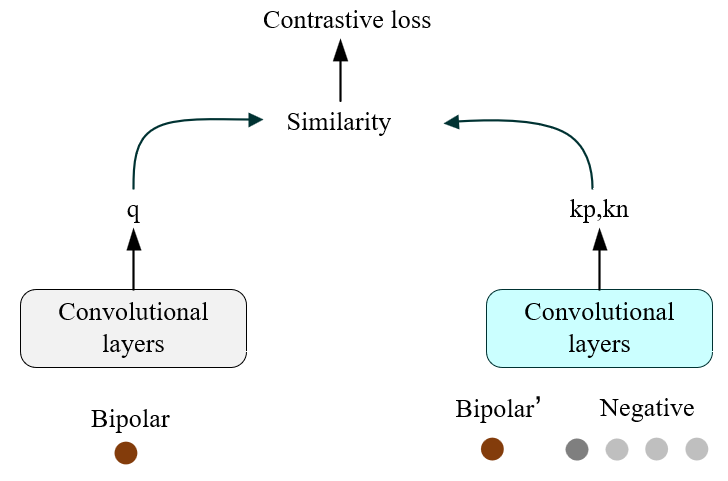

Task 3 also consists of **Code Implementation [20%]** and **Analysis Report [15%]**. Keep all implementation and visualization code in the notebook. Place the resulting figures and your written discussion in the separate Analysis Report.

### **[5%] Q3.1: Construct contrastive pairs**

Different from the dataloader in Task 1, the contrastive learning requires establishing the positive image pairs (by applying different augmentations to an image).

Implement `PairDataset` so that each item returns two independently augmented views of the same RGB image. Choose augmentations that create meaningful variation while keeping the surgical instrument recognizable, then apply ImageNet normalization to both views. Class labels are not returned.

In [ ]:
class PairDataset(Dataset.Dataset):
  def __init__(self, img_list, is_train=True):
    self.img_list = img_list
    self.is_train = is_train

    ##############################################################################
    # TODO: Define the transform used to create each view.
    # Requirements:
    # - Resize to (175, 300).
    # - Include suitable random train-time augmentations
    #   Can use simple augmentations such as random flip and random rotation
    # - Convert to a tensor and apply ImageNet normalization
    ##############################################################################

    extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    self.img_list = sorted(path for path in img_list
                           if os.path.isfile(path)
                           and os.path.splitext(path)[1].lower() in extensions)
    if not self.img_list:
      raise ValueError('No valid images were provided for contrastive learning.')
    self.resize = torchvision.transforms.Resize((175, 300))
    self.augmentation_transforms = torchvision.transforms.Compose([
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.RandomRotation(degrees=15),
        torchvision.transforms.ColorJitter(brightness=0.15, contrast=0.15,
                                           saturation=0.1, hue=0.02),
    ])
    self.image_transforms = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225]),
    ])

    ##############################################################################
    #                         END OF YOUR CODE
    ##############################################################################

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    img_name = self.img_list[index]
    image = Image.open(img_name)
    image = self.resize(image)

    ##############################################################################
    # TODO: Generate two different augmented views of the same image.
    # - Apply the augmentation transforms independently on the resized image
    # - Each call should produce a different random view (positive pair)
    ##############################################################################

    # Perform augmentation to get image1
    image = image.convert('RGB')
    image1 = (self.augmentation_transforms(image) if self.is_train
              else image.copy())

    # Perform augmentation to get image2
    image2 = (self.augmentation_transforms(image) if self.is_train
              else image.copy())


    ##############################################################################
    #             END OF YOUR CODE
    ##############################################################################

    image1 = self.image_transforms(image1)
    image2 = self.image_transforms(image2)

    return image1, image2

Build the pretraining dataloader below. `drop_last=True` is required because the simplified queue implementation in Q3.2 uses a fixed batch size that must divide the queue size.

In [ ]:
# Read all images' path
img_list_train_full = []
for root, dirs, files in os.walk(full_dataset_dir):
  for file in files:
    img_list_train_full.append(os.path.join(full_dataset_dir, file))
size_train_full = len(img_list_train_full)

contrastive_batch_size = 8
train_full_data = PairDataset(img_list_train_full, True)

# Train_dataloader should drop_last to prevent error in the queue of contrastive learning
train_full_loader = torch.utils.data.DataLoader(dataset=train_full_data,
                                                batch_size=contrastive_batch_size,
                                                shuffle=True,
                                                drop_last=True)

Before training, inspect several positive pairs to check that the two views are different but still preserve the instrument information. Write your own visualization code; reverse ImageNet normalization before displaying images.

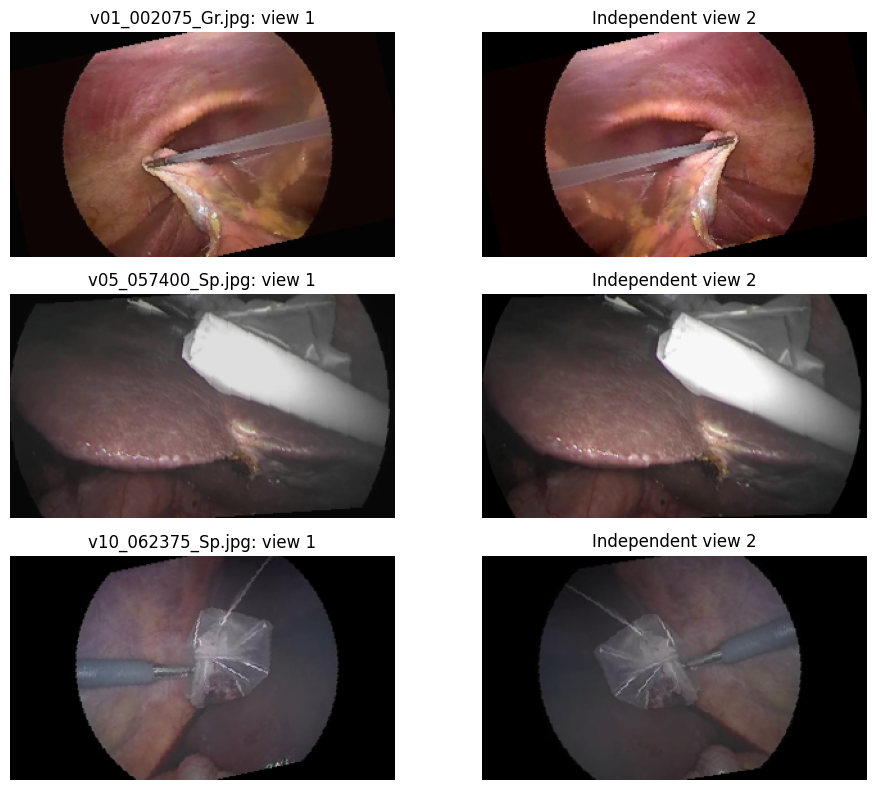

Augmentations: horizontal flip, rotation within 15 degrees, mild color jitter. Check that instrument tips, shape and useful color remain visible.


In [ ]:
################################################################################
# TODO: (for later analysis)
# Write your own code to visualize at least three positive pairs.
# You can add cells if needed
################################################################################

analysis_dir_task3 = os.path.join(weights_root, 'task3_analysis')
os.makedirs(analysis_dir_task3, exist_ok=True)

def display_task3_image(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.detach().cpu() * std + mean
    return image.clamp(0, 1).permute(1, 2, 0).numpy()

if len(train_full_data) < 3:
    raise ValueError('At least three images are needed to inspect positive pairs.')
pair_indices = np.linspace(0, len(train_full_data) - 1, 3, dtype=int)
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
# Keep the visualization reproducible without changing training's RNG state.
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(42)
    for row, index in enumerate(pair_indices):
        first, second = train_full_data[int(index)]
        axes[row, 0].imshow(display_task3_image(first))
        axes[row, 1].imshow(display_task3_image(second))
        name = os.path.basename(train_full_data.img_list[int(index)])
        axes[row, 0].set_title(f'{name}: view 1')
        axes[row, 1].set_title('Independent view 2')
for ax in axes.flat:
    ax.axis('off')
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task3, 'positive_pairs.png'), dpi=200)
plt.show()
print('Augmentations: horizontal flip, rotation within 15 degrees, mild color '
      'jitter. Check that instrument tips, shape and useful color remain visible.')

################################################################################
#                         END OF YOUR CODE
################################################################################


### **[8%] Q3.2: Implement the encoder and MoCo model**

Based on the defined ConvNet in Task 1, we construct the contrastive learning model. Compared with the ConvNet in Task 1, we just reduce two linear layers in the end.

First implement `ConvNetNew`, which follows the five convolutional blocks used by the Task 1 `ConvNet` but replaces its classification layers with adaptive average pooling and a 128-dimensional projection. Keep the layer names `conv1`–`conv5`, `bn1`–`bn5`, `relu1`–`relu5`, and `max1`–`max5`, so that the pretrained convolutional weights can be loaded into the Task 1 classifier in Q3.4.

In [ ]:
class ConvNetNew(torch.nn.Module):
  def __init__(self):
    super().__init__()
    ##############################################################################
    # TODO: Build a CNN encoder (representation learning).
    # Requirements:
    # - Stack multiple Conv-BN-ReLU-MaxPool blocks
    # - Apply AdaptiveAvgPool2d to reduce features to 1×1
    # - Replace the final linear layers with a 256→128 projection head
    # - Output a 128-D feature embedding (no classifier here)
    # - Input: (B,3,H,W), H,W≥64; Output: (B,128); Do NOT hard-code H,W
    ##############################################################################

    # Block 1: 3 x 175 x 300 --> 32 x 87 x 150
    # Define self.conv1, self.bn1, self.relu1, and self.max1
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.bn1 = nn.BatchNorm2d(32)
    self.relu1 = nn.ReLU()
    self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 2: 32 x 87 x 150 --> 64 x 43 x 75
    # Define self.conv2, self.bn2, self.relu2, and self.max2
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(64)
    self.relu2 = nn.ReLU()
    self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 3: 64 x 43 x 75 --> 128 x 21 x 37
    # Define self.conv3, self.bn3, self.relu3, and self.max3
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.bn3 = nn.BatchNorm2d(128)
    self.relu3 = nn.ReLU()
    self.max3 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 4: 128 x 21 x 37 --> 256 x 10 x 18
    # Define self.conv4, self.bn4, self.relu4, and self.max4
    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
    self.bn4 = nn.BatchNorm2d(256)
    self.relu4 = nn.ReLU()
    self.max4 = nn.MaxPool2d(kernel_size=2, stride=2)


    # Block 5: 256 x 10 x 18 --> 256 x 5 x 9
    # Define self.conv5, self.bn5, self.relu5, and self.max5
    self.conv5 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
    self.bn5 = nn.BatchNorm2d(256)
    self.relu5 = nn.ReLU()
    self.max5 = nn.MaxPool2d(kernel_size=2, stride=2)



    # Define self.aap using AdaptiveAvgPool2d
    # 256 x 5 x 9 --> 256 x 1 x 1
    self.aap = nn.AdaptiveAvgPool2d((1, 1))


    # Define the contrastive projection layer as self.fc1
    # 256 --> 128
    self.fc1 = nn.Linear(256, 128)


    ##############################################################################
    #            END OF YOUR CODE
    ##############################################################################

  def forward(self, x):
    ##############################################################################
    # TODO: implement the forward
    ##############################################################################

    # Block 1: 3 x 175 x 300 --> 32 x 87 x 150
    x = self.max1(self.relu1(self.bn1(self.conv1(x))))


    # Block 2: 32 x 87 x 150 --> 64 x 43 x 75
    x = self.max2(self.relu2(self.bn2(self.conv2(x))))


    # Block 3: 64 x 43 x 75 --> 128 x 21 x 37
    x = self.max3(self.relu3(self.bn3(self.conv3(x))))


    # Block 4: 128 x 21 x 37 --> 256 x 10 x 18
    x = self.max4(self.relu4(self.bn4(self.conv4(x))))


    # Block 5: 256 x 10 x 18 --> 256 x 5 x 9
    x = self.max5(self.relu5(self.bn5(self.conv5(x))))


    # AdaptiveAvgPool: 256 x 1 x 1
    x = self.aap(x)


    # Linear layers: 256 x 1 x 1 --> 128
    x = self.fc1(torch.flatten(x, start_dim=1))


    ##############################################################################
    #            END OF YOUR CODE
    ##############################################################################
    return x


With the defined convolution layers (ConvNetNew()), the whole contrastive learning framework could be constructed. The encoder_q and encoder_k have the same convolutional layers. However, the encoder_k will not be optimized by the training (the gradient of encoder_k should be set False). To update the parameters of encoder_k, the parameters will copy encoder_q's.

In [ ]:
class ConLNet(torch.nn.Module):
  def __init__(self):
    super(ConLNet, self).__init__()
    ##############################################################################
    # TODO: Define the convolutional encoders q & k
    # Tips: refer to: https://arxiv.org/abs/1911.05722 and https://github.com/facebookresearch/moco
    # Requirements:
    # - Build encoder_q and encoder_k based on ConvNetNew
    # - Initialize encoder_k with encoder_q’s parameters
    # - Set encoder_k parameters to not require gradients
    # - Follow MoCo design (refer to paper and codebase)
    # - Use a momentum update for encoder_k in forward: k = m*k + (1-m)*q (under torch.no_grad())
    # - Maintain a feature queue (dim=128, size=K) as buffers (register_buffer) and L2-normalize q/k
    # - Set encoder_k.eval() during forward to freeze BN running stats
    ##############################################################################

    # Create encoder_q and encoder_k  Hint: define the encoder_q and encoder_k based on ConvNetNew()
    self.encoder_q = ConvNetNew()
    self.encoder_k = ConvNetNew()


    # Copy encoder_q's paremeter to encoder_k, and set requires_grad of parameter to False
    # Copy both parameters and initial BatchNorm buffers.
    self.encoder_k.load_state_dict(self.encoder_q.state_dict())
    for parameter in self.encoder_k.parameters():
      parameter.requires_grad_(False)



    # Set temperature for infoNCE (T=0.07), momentum updating (m=0.99), feature dimension (dim=128), queue size (K=160)
    # Temperature for infoNCE
    self.T = 0.07

    # Momentum updating
    self.m = 0.99

    # Feature dimension
    self.dim = 128

    # Queue size
    self.K = 160

    # Set a queue pointer (queue_ptr) to manage the queue, which helps locate the position of queue
    self.register_buffer('queue_ptr', torch.zeros(1, dtype=torch.long))

    # Create the 128 negative instance features by torch.randn, feature size is dim, queue size is K
    initial_queue = nn.functional.normalize(torch.randn(self.dim, self.K), dim=0)
    self.register_buffer('queue', initial_queue)



  def infoNCE(self, q, k):
    # Positive logits: Nx1 （Multiply the corresponding elements of the matrix and sum them row by row) on q and k
    positive_logits = (q * k).sum(dim=1, keepdim=True)

    # Negative logits: NxK  (matrix product) on q and the negative sample
    # Clone: forward updates the queue before backward uses these negatives.
    negative_logits = q @ self.queue.detach().clone()


    # Concat logits: Nx(1+K)
    logits = torch.cat([positive_logits, negative_logits], dim=1)

    # Apply temperature to logits
    logits = logits / self.T


    # Set labels
    labels = torch.zeros(q.size(0), dtype=torch.long, device=q.device)

    # Calculate infoNCE by CrossEntropy using nn.functional.cross_entropy
    loss = nn.functional.cross_entropy(logits, labels)


    return loss

  # Organize the queue when new keys are coming
  def _dequeue_and_enqueue(self, keys):
    # Get batch_size
    batch_size = keys.size(0)


    # For simplicity, assert self.K % batch_size == 0
    assert batch_size > 0 and self.K % batch_size == 0, (
        'The fixed contrastive batch size must divide the queue size.'
    )

    # Replace the keys at ptr (dequeue and enqueue) in the queue
    ptr = int(self.queue_ptr.item())
    with torch.no_grad():
      indices = (torch.arange(batch_size, device=self.queue.device) + ptr) % self.K
      normalized_keys = nn.functional.normalize(keys.detach(), dim=1)
      self.queue.index_copy_(1, indices, normalized_keys.T)

    # Move pointer, and save it to self.queue_ptr for the next usage
    self.queue_ptr[0] = (ptr + batch_size) % self.K



  def forward(self, im1, im2):
    # Copy encoder_q's parameters to encoder_k with momentum update with torch.no_grad():
    # Encoder_k = self.m * encoder_k + (1 - self.m) * encoder_q
    with torch.no_grad():
      for parameter_q, parameter_k in zip(self.encoder_q.parameters(),
                                          self.encoder_k.parameters()):
        parameter_k.mul_(self.m).add_(parameter_q, alpha=1 - self.m)


    # Compute features of q and k with encoder_q and encoder_k using im1 and im2, and then normalize the feature
    # Since the encoder_k is update with momentum update, remember to open torch.no_grad() when using encoder_k
    q = nn.functional.normalize(self.encoder_q(im1), dim=1)
    # model.train() also affects children; explicitly freeze key BN statistics.
    self.encoder_k.eval()
    with torch.no_grad():
      k = nn.functional.normalize(self.encoder_k(im2), dim=1)


    # Calculate the loss of q and k
    loss = self.infoNCE(q, k)


    # Use  _dequeue_and_enqueue to store k
    self._dequeue_and_enqueue(k)


    return loss

    ##############################################################################
    #             END OF YOUR CODE
    ##############################################################################

### **[4%] Q3.3: Run contrastive pretraining**

From Q3.1 to Q3.2, the contrastive learning model and dataloader are defined. In this section, we will build up the forward process of contrastive learning. Without the label of each data, the loss is calculated by comparing the similarity of the features extracted by two parallel encoders. Save the trained query encoder for Q3.4.

In [ ]:
def train_contrastive_net(model, train_loader, optimizer, save_path, total_epochs=200):
  # Train contrastive learning
  epoch_losses = []
  model.train()
  for epoch in range(total_epochs):
    running_loss = 0.0
    for image1_norm, image2_norm in train_loader:
      ##############################################################################
      # TODO: Complete the forward process
      # Requirements:
      # - Move both augmented views to device
      # - Forward through the model to get contrastive loss (infoNCE)
      # - Zero gradients, backpropagate, and update parameters
      # - Accumulate running loss for logging
      ##############################################################################


      # Calculate the loss by the defined model above
      image1_norm = image1_norm.to(device)
      image2_norm = image2_norm.to(device)
      optimizer.zero_grad()
      loss = model(image1_norm, image2_norm)


      # Backward the loss and optimize the model
      loss.backward()
      optimizer.step()
      # drop_last=True fixes batch size, so an average of batch losses is valid.
      running_loss += loss.item()
      os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)



      ##############################################################################
      #            END OF YOUR CODE
      ##############################################################################
    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print('epoch= {} \t loss= {:.3f}'.format(epoch, avg_loss))

  # We only save encoder_q
  assert model.encoder_q is not None
  torch.save(model.encoder_q.state_dict(), save_path)
  print(f'Query encoder saved to {save_path}')

  return epoch_losses

In [ ]:
# Initialize the MoCo model
contrastive_model = ConLNet().to(device)

# Hyperparameters
contrastive_learning_rate = 1e-3
contrastive_epochs = 200
contrastive_optimizer = optim.Adam(
  contrastive_model.encoder_q.parameters(),
  lr=contrastive_learning_rate,
)

contrastive_encoder_path = os.path.join(
  weights_root, 'task3_contrastive_encoder.pth'
)

# Run contrastive learning training
contrastive_loss_history = train_contrastive_net(
  contrastive_model,
  train_full_loader,
  contrastive_optimizer,
  contrastive_encoder_path,
  total_epochs=contrastive_epochs,
)

epoch= 0 	 loss= 3.771
epoch= 1 	 loss= 3.863
epoch= 2 	 loss= 3.378
epoch= 3 	 loss= 3.472
epoch= 4 	 loss= 3.703
epoch= 5 	 loss= 3.843
epoch= 6 	 loss= 4.133
epoch= 7 	 loss= 4.191
epoch= 8 	 loss= 4.012
epoch= 9 	 loss= 4.227
epoch= 10 	 loss= 4.509
epoch= 11 	 loss= 4.331
epoch= 12 	 loss= 3.763
epoch= 13 	 loss= 3.946
epoch= 14 	 loss= 3.977
epoch= 15 	 loss= 4.100
epoch= 16 	 loss= 4.130
epoch= 17 	 loss= 4.223
epoch= 18 	 loss= 4.174
epoch= 19 	 loss= 4.179
epoch= 20 	 loss= 4.127
epoch= 21 	 loss= 4.329
epoch= 22 	 loss= 4.213
epoch= 23 	 loss= 4.260
epoch= 24 	 loss= 4.301
epoch= 25 	 loss= 4.348
epoch= 26 	 loss= 4.329
epoch= 27 	 loss= 4.078
epoch= 28 	 loss= 4.021
epoch= 29 	 loss= 4.033
epoch= 30 	 loss= 3.811
epoch= 31 	 loss= 3.648
epoch= 32 	 loss= 3.531
epoch= 33 	 loss= 3.400
epoch= 34 	 loss= 3.327
epoch= 35 	 loss= 3.465
epoch= 36 	 loss= 3.456
epoch= 37 	 loss= 3.433
epoch= 38 	 loss= 3.424
epoch= 39 	 loss= 3.487
epoch= 40 	 loss= 3.507
epoch= 41 	 loss= 3.457
ep

#### Prepare the learned-representation analysis

Use the next cell to analyse the frozen pretrained encoder before supervised fine-tuning (Detailed requirements are in Q3.5). You may add additional cells if needed.

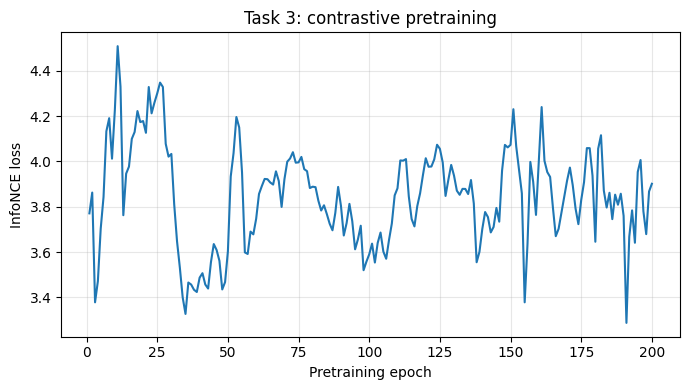

Exact-image overlap audit: {'pretraining_train_shared_unique_hashes': 178, 'pretraining_val_shared_unique_hashes': 0, 'train_val_shared_unique_hashes': 0}
Hash comparisons do not rule out visually similar or adjacent frames.


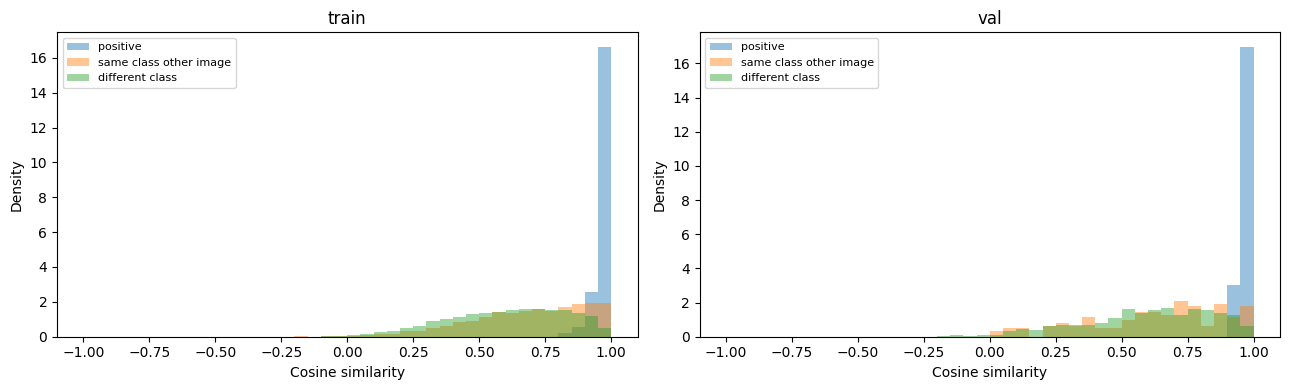

{'split': 'train', 'num_images': 178, 'positive_mean_cosine': 0.973155677318573, 'same_class_other_image_mean_cosine': 0.6839206218719482, 'different_class_mean_cosine': 0.603193998336792, 'one_nn_label_agreement': 0.5955056179775281}
{'split': 'val', 'num_images': 33, 'positive_mean_cosine': 0.9724311828613281, 'same_class_other_image_mean_cosine': 0.6306564211845398, 'different_class_mean_cosine': 0.5981564521789551, 'one_nn_label_agreement': 0.6666666666666666}
1-NN is a frozen-feature diagnostic: train excludes self matches; validation retrieves only from the training gallery. No test data is used.
{'split': 'train', 'class': 'Bipolar', 'support': 26, 'one_nn_label_agreement': 0.6153846153846154}
{'split': 'train', 'class': 'Clipper', 'support': 27, 'one_nn_label_agreement': 0.7407407407407407}
{'split': 'train', 'class': 'Grasper', 'support': 27, 'one_nn_label_agreement': 0.3333333333333333}
{'split': 'train', 'class': 'Hook', 'support': 29, 'one_nn_label_agreement': 0.41379310344

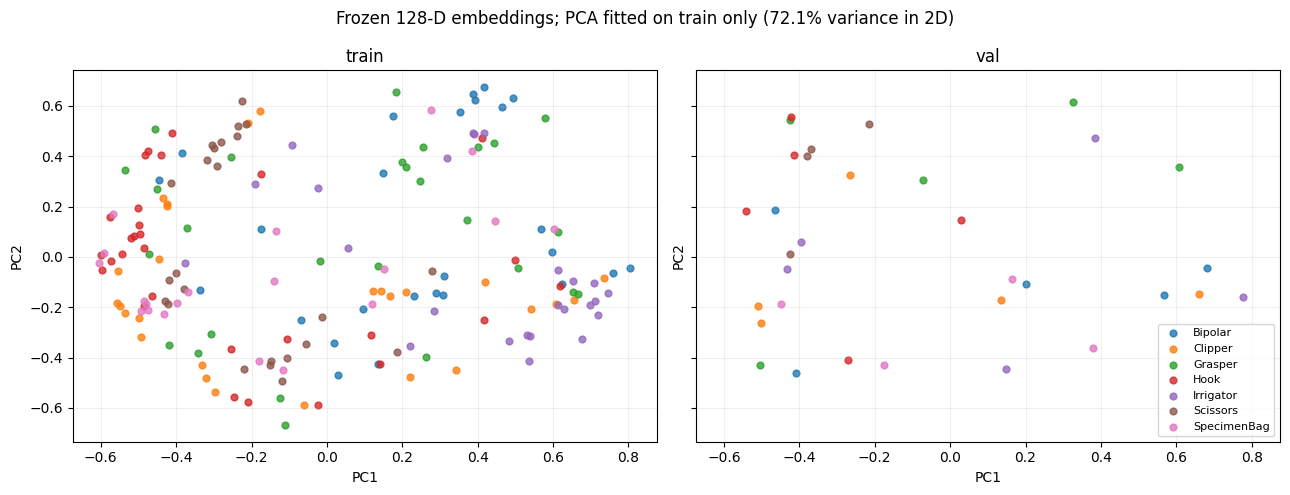

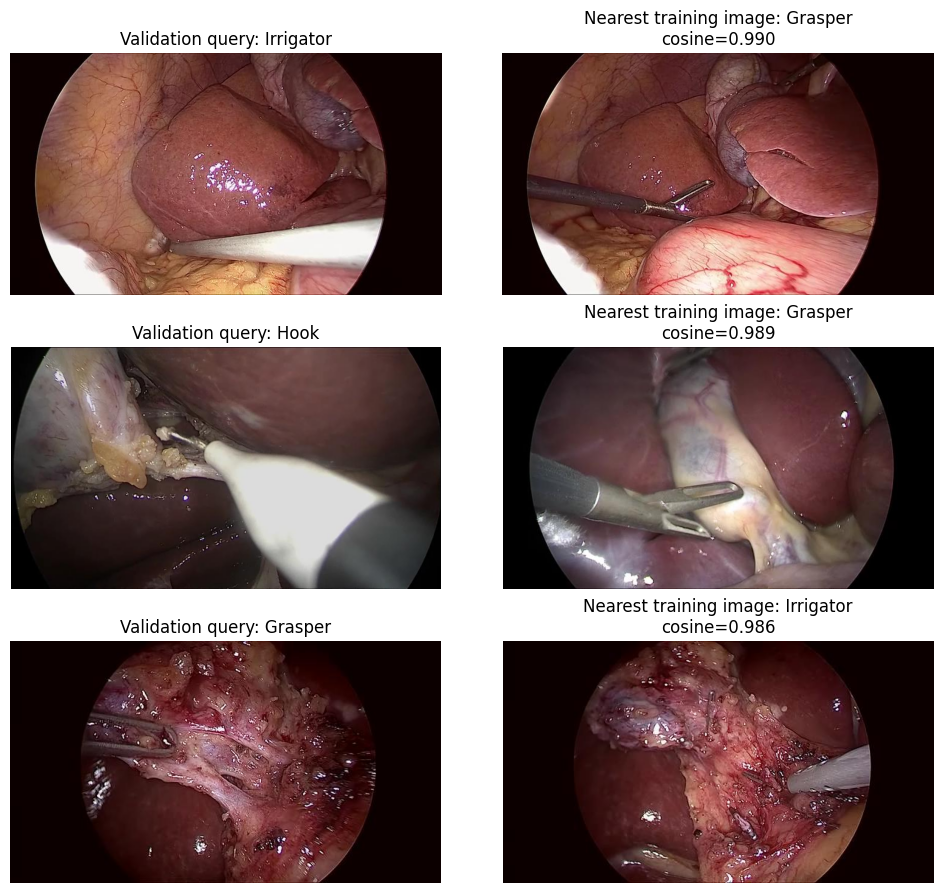

ConvNetNew(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (max3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): 

In [ ]:
################################################################################
# TODO: (for later analysis)
# Design suitable visualizations or quantitative diagnostics
# Possible approaches include similarity distributions, nearest-neighbour
# retrieval, feature-space visualization, or other appropriate methods
################################################################################

import csv
import json
import hashlib
from sklearn.decomposition import PCA

analysis_dir_task3 = os.path.join(weights_root, 'task3_analysis')
os.makedirs(analysis_dir_task3, exist_ok=True)
with open(os.path.join(analysis_dir_task3, 'contrastive_history.json'),
          'w', encoding='utf-8') as file:
    json.dump({'loss': contrastive_loss_history}, file, indent=2)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(contrastive_loss_history) + 1), contrastive_loss_history)
ax.set(xlabel='Pretraining epoch', ylabel='InfoNCE loss',
       title='Task 3: contrastive pretraining')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task3, 'contrastive_loss.png'), dpi=200)
plt.show()

# Use a separate frozen model; representation analysis never updates training
# weights, BN statistics or the MoCo queue and never uses the test split.
representation_encoder = ConvNetNew().to(device)
representation_encoder.load_state_dict(torch.load(
    contrastive_encoder_path, map_location=device, weights_only=True,
))
representation_encoder.eval()
for parameter in representation_encoder.parameters():
    parameter.requires_grad_(False)
class_names_task3 = ['Bipolar', 'Clipper', 'Grasper', 'Hook',
                     'Irrigator', 'Scissors', 'SpecimenBag']

@torch.inference_mode()
def extract_task3_features(paths):
    dataset = ImageDataset(paths, is_train=False)
    loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=False)
    features, labels = [], []
    for _, images, targets in loader:
        embeddings = nn.functional.normalize(
            representation_encoder(images.to(device)), dim=1,
        )
        features.append(embeddings.cpu().numpy())
        labels.append(targets.numpy())
    return np.concatenate(features), np.concatenate(labels)

@torch.inference_mode()
def task3_pair_similarities(paths):
    pairs = PairDataset(paths, is_train=True)
    loader = torch.utils.data.DataLoader(pairs, batch_size=16, shuffle=False)
    first_features, second_features = [], []
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(42)
        for first, second in loader:
            first_features.append(nn.functional.normalize(
                representation_encoder(first.to(device)), dim=1,
            ).cpu().numpy())
            second_features.append(nn.functional.normalize(
                representation_encoder(second.to(device)), dim=1,
            ).cpu().numpy())
    first_features = np.concatenate(first_features)
    second_features = np.concatenate(second_features)
    label_map = ImageDataset(pairs.img_list, is_train=False).label_dict
    pair_labels = np.asarray([
        label_map[
            os.path.splitext(path)[0].split('_')[-1]]
        for path in pairs.img_list
    ])
    similarities = np.clip(first_features @ second_features.T, -1, 1)
    identity = np.eye(len(pair_labels), dtype=bool)
    same_class = pair_labels[:, None] == pair_labels[None, :]
    return {
        'positive': similarities[identity],
        'same_class_other_image': similarities[same_class & ~identity],
        'different_class': similarities[~same_class],
    }

# Verify whether validation really is held out from the unlabeled image pool.
# Exact byte hashes detect duplicated files, not near-duplicate video frames.
def image_hashes(paths):
    hashes = set()
    for path in paths:
        with open(path, 'rb') as file:
            hashes.add(hashlib.sha256(file.read()).hexdigest())
    return hashes

pretraining_hashes = image_hashes(train_full_data.img_list)
train_hashes = image_hashes(img_list_train)
val_hashes = image_hashes(img_list_val)
overlap_summary_task3 = {
    'pretraining_train_shared_unique_hashes': len(pretraining_hashes & train_hashes),
    'pretraining_val_shared_unique_hashes': len(pretraining_hashes & val_hashes),
    'train_val_shared_unique_hashes': len(train_hashes & val_hashes),
}
print('Exact-image overlap audit:', overlap_summary_task3)
print('Hash comparisons do not rule out visually similar or adjacent frames.')
with open(os.path.join(analysis_dir_task3, 'image_overlap_audit.json'),
          'w', encoding='utf-8') as file:
    json.dump(overlap_summary_task3, file, indent=2)

train_features_task3, train_labels_task3 = extract_task3_features(img_list_train)
val_features_task3, val_labels_task3 = extract_task3_features(img_list_val)
features_by_split = {'train': train_features_task3, 'val': val_features_task3}
labels_by_split = {'train': train_labels_task3, 'val': val_labels_task3}
paths_by_split = {'train': img_list_train, 'val': img_list_val}
similarities_by_split = {}
representation_rows = []
retrieval_by_split = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ['train', 'val']):
    similarities = task3_pair_similarities(paths_by_split[split])
    similarities_by_split[split] = similarities
    row = {'split': split, 'num_images': len(paths_by_split[split])}
    for name, values in similarities.items():
        row[name + '_mean_cosine'] = float(values.mean()) if len(values) else None
        if len(values):
            ax.hist(values, bins=np.linspace(-1, 1, 41), density=True,
                    alpha=0.45, label=name.replace('_', ' '))
    ax.set(xlabel='Cosine similarity', ylabel='Density', title=split)
    ax.legend(fontsize=8)
    # Deterministic unaugmented embeddings for nearest-neighbour retrieval.
    similarity_to_train = features_by_split[split] @ train_features_task3.T
    if split == 'train':
        np.fill_diagonal(similarity_to_train, -np.inf)  # Exclude self retrieval.
    nearest = similarity_to_train.argmax(axis=1)
    predicted = train_labels_task3[nearest]
    retrieval_by_split[split] = {'indices': nearest, 'predictions': predicted,
                                 'similarities': similarity_to_train[
                                     np.arange(len(nearest)), nearest]}
    row['one_nn_label_agreement'] = float(np.mean(predicted == labels_by_split[split]))
    representation_rows.append(row)
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task3, 'representation_similarities.png'), dpi=200)
plt.show()
with open(os.path.join(analysis_dir_task3, 'representation_summary.csv'), 'w',
          newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=list(representation_rows[0]))
    writer.writeheader()
    writer.writerows(representation_rows)
for row in representation_rows:
    print(row)
print('1-NN is a frozen-feature diagnostic: train excludes self matches; '
      'validation retrieves only from the training gallery. No test data is used.')

class_retrieval_rows = []
for split in ['train', 'val']:
    for class_id, class_name in enumerate(class_names_task3):
        mask = labels_by_split[split] == class_id
        class_retrieval_rows.append({
            'split': split, 'class': class_name, 'support': int(mask.sum()),
            'one_nn_label_agreement': float(np.mean(
                retrieval_by_split[split]['predictions'][mask] == class_id,
            )) if mask.any() else None,
        })
with open(os.path.join(analysis_dir_task3, 'retrieval_by_class.csv'), 'w',
          newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=list(class_retrieval_rows[0]))
    writer.writeheader()
    writer.writerows(class_retrieval_rows)
for row in class_retrieval_rows:
    print(row)

# Fit PCA on training embeddings only; transform validation in the same space.
pca_task3 = PCA(n_components=2, svd_solver='full')
train_coordinates = pca_task3.fit_transform(train_features_task3)
val_coordinates = pca_task3.transform(val_features_task3)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, split, coordinates in zip(axes, ['train', 'val'],
                                  [train_coordinates, val_coordinates]):
    for class_id, class_name in enumerate(class_names_task3):
        mask = labels_by_split[split] == class_id
        ax.scatter(coordinates[mask, 0], coordinates[mask, 1],
                   color=plt.get_cmap('tab10')(class_id), label=class_name,
                   s=24, alpha=0.8)
    ax.set(xlabel='PC1', ylabel='PC2', title=split)
    ax.grid(alpha=0.2)
axes[1].legend(fontsize=8)
fig.suptitle('Frozen 128-D embeddings; PCA fitted on train only '
             f'({pca_task3.explained_variance_ratio_.sum():.1%} variance in 2D)')
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task3, 'representation_pca.png'), dpi=200)
plt.show()
np.savez_compressed(
    os.path.join(analysis_dir_task3, 'frozen_representations.npz'),
    train_features=train_features_task3, train_labels=train_labels_task3,
    val_features=val_features_task3, val_labels=val_labels_task3,
    train_paths=np.asarray(img_list_train), val_paths=np.asarray(img_list_val),
    **{split + '_' + name: values for split, groups in similarities_by_split.items()
       for name, values in groups.items()},
)

# Inspect nearest-neighbour class errors on validation images.
val_retrieval = retrieval_by_split['val']
retrieval_errors = np.flatnonzero(val_retrieval['predictions'] != val_labels_task3)
if len(retrieval_errors):
    order = retrieval_errors[np.argsort(-val_retrieval['similarities'][retrieval_errors])]
    chosen = order[:3]
    fig, axes = plt.subplots(len(chosen), 2, figsize=(10, 3 * len(chosen)), squeeze=False)
    for row, index in enumerate(chosen):
        neighbour = int(val_retrieval['indices'][index])
        for col, path in enumerate([img_list_val[index], img_list_train[neighbour]]):
            with Image.open(path) as image:
                axes[row, col].imshow(image.convert('RGB'))
            axes[row, col].axis('off')
        axes[row, 0].set_title('Validation query: ' + class_names_task3[val_labels_task3[index]])
        axes[row, 1].set_title('Nearest training image: '
                               + class_names_task3[train_labels_task3[neighbour]]
                               + f"\ncosine={val_retrieval['similarities'][index]:.3f}")
    fig.tight_layout()
    fig.savefig(os.path.join(analysis_dir_task3, 'retrieval_failures.png'), dpi=200)
    plt.show()
else:
    print('No validation nearest-neighbour class errors in this run.')
# Leave the frozen representation model on CPU after analysis.
representation_encoder.cpu()

################################################################################
#                         END OF YOUR CODE
################################################################################

### **[3%] Q3.4**: Fine-tunning on the trained network.

With the pre-trained network by contrastive learning, we can fine-tune it to realize classification by few labels. We need to load the pre-trained model for fine-tunning.

In [ ]:
# Load pre-trained model
model_ft = ConvNet().to(device)

contrastive_model_path = os.path.join(weights_root, 'task3_contrastive_model.pth')

# Load the query-encoder checkpoint saved in Q3.3
pretrained_dict = torch.load(
  contrastive_encoder_path,
  map_location=device,
  weights_only=True,
)

for key in list(pretrained_dict.keys()):
  # Only leave the backbone module, popping the linear layers
  if 'fc' in key:
    pretrained_dict.pop(key)
    print('Pretrained key {} removed'.format(key))

missing_keys, unexpected_keys = model_ft.load_state_dict(pretrained_dict, strict=False)
print('Model loaded from %s' % contrastive_model_path)
print('missing key: ', missing_keys)
ft_model_is_trained = False
# Since the contrastive model has different linear layers, the missing keys are fc1, fc2, fc3

Pretrained key fc1.weight removed
Pretrained key fc1.bias removed
Model loaded from /content/drive/MyDrive/BN5211/weights/task3_contrastive_model.pth
missing key:  ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']


Based on the pre-trained model, we can conduct few round fine-tunning.

In [ ]:
finetune_batch_size = 8
criterion = torch.nn.CrossEntropyLoss()

# Build data loaders
dataset_train = ImageDataset(img_list_train, True)
dataset_val = ImageDataset(img_list_val, False)
dataset_test = ImageDataset(img_list_test, False)

# Build the training dataloader
dataloader_train = torch.utils.data.DataLoader(
  dataset=dataset_train,
  batch_size=finetune_batch_size,
  shuffle=True,
)

# Build the validation dataloader
dataloader_val = torch.utils.data.DataLoader(
  dataset=dataset_val,
  batch_size=finetune_batch_size,
  shuffle=False,
)

# Build the test dataloader
dataloader_test = torch.utils.data.DataLoader(
  dataset=dataset_test,
  batch_size=finetune_batch_size,
  shuffle=False,
)

In [ ]:
# Set the fine-tuning hyperparameters
total_epochs = 200
learning_rate = 1e-3

if ft_model_is_trained:
    print('Warning: the ft_model is already trained!')
else:
    ft_model_is_trained = True
finetune_model_path = os.path.join(weights_root, 'model_ft_task3.pth')
##############################################################################
# TODO: Fine-tune `model_ft`.
# - Set hyperparameters (epochs, batch_size, learning_rate)
# - Define an optimizer for trainable params of `model_ft` (e.g., Adam)
# - Train with `train_net` and save the best checkpoint
# - Reload the saved weights and evaluate on the test set
##############################################################################


# Set up optimizer
import json
import hashlib

expected_missing = {f'fc{layer}.{field}' for layer in [1, 2, 3]
                    for field in ['weight', 'bias']}
if set(missing_keys) != expected_missing or unexpected_keys:
    raise RuntimeError('Unexpected backbone mismatch when loading the encoder.')
print('Fine-tuning backbone loaded from:', contrastive_encoder_path)

history_path_ft = os.path.join(weights_root, 'task3_finetune_history.json')
run_path_ft = os.path.join(weights_root, 'task3_finetune_run.json')
selection_path_ft = os.path.join(weights_root, 'task3_final_selection.json')
results_path_ft = os.path.join(weights_root, 'task3_test_results.npz')
with open(contrastive_encoder_path, 'rb') as file:
    encoder_hash_ft = hashlib.sha256(file.read()).hexdigest()
run_record_ft = {
    'encoder_sha256': encoder_hash_ft, 'epochs': total_epochs,
    'learning_rate': learning_rate, 'batch_size': finetune_batch_size,
    'optimizer': 'Adam', 'train_paths': img_list_train, 'val_paths': img_list_val,
}
optimizer_ft = optim.Adam(model_ft.parameters(), lr=learning_rate)


# Start training
# Once final evaluation has been recorded, rerunning this cell reuses it
# instead of retraining and choosing a new model after viewing the test set.
if os.path.exists(selection_path_ft) or os.path.exists(results_path_ft):
    if not all(os.path.exists(path) for path in
               [run_path_ft, history_path_ft, finetune_model_path, selection_path_ft]):
        raise RuntimeError('Incomplete saved fine-tuning/evaluation artifacts.')
    with open(run_path_ft, encoding='utf-8') as file:
        if json.load(file) != run_record_ft:
            raise RuntimeError('Fine-tuning setup changed after final evaluation.')
    with open(history_path_ft, encoding='utf-8') as file:
        history_ft = json.load(file)
    print('Reusing the selected fine-tuned checkpoint and saved history.')
else:
    history_ft = train_net(
        model_ft, dataloader_train, dataloader_val, optimizer_ft,
        criterion, finetune_model_path, total_epochs=total_epochs,
    )
    with open(history_path_ft, 'w', encoding='utf-8') as file:
        json.dump(history_ft, file, indent=2)
    with open(run_path_ft, 'w', encoding='utf-8') as file:
        json.dump(run_record_ft, file, indent=2)


# Start testing
best_index_ft = int(np.argmax(history_ft['val_accuracy']))
model_ft.load_state_dict(torch.load(finetune_model_path,
                                    map_location=device, weights_only=True))
model_ft.eval()
with open(finetune_model_path, 'rb') as file:
    checkpoint_hash_ft = hashlib.sha256(file.read()).hexdigest()
selection_ft = {
    'checkpoint_sha256': checkpoint_hash_ft,
    'best_epoch': best_index_ft + 1,
    'val_accuracy': float(history_ft['val_accuracy'][best_index_ft]),
    'val_loss': float(history_ft['val_loss'][best_index_ft]),
    'selection_rule': 'highest validation accuracy; earliest tied epoch',
    'test_paths': dataloader_test.dataset.img_list,
}
if os.path.exists(selection_path_ft):
    with open(selection_path_ft, encoding='utf-8') as file:
        if json.load(file) != selection_ft:
            raise RuntimeError('The recorded final fine-tuned model has changed.')
# Record validation evidence before the final evaluation.
with open(selection_path_ft, 'w', encoding='utf-8') as file:
    json.dump(selection_ft, file, indent=2)
if os.path.exists(results_path_ft):
    with np.load(results_path_ft, allow_pickle=False) as saved:
        results_ft = {key: saved[key].copy() for key in saved.files}
    results_ft['loss'] = float(results_ft['loss'])
    results_ft['accuracy'] = float(results_ft['accuracy'])
    print('Reusing final test predictions; no repeat test evaluation.')
else:
    results_ft = eval_on_dataset(model_ft, dataloader_test)
    results_ft['image_paths'] = np.asarray(dataloader_test.dataset.img_list, dtype=str)
    np.savez_compressed(results_path_ft, **results_ft)
print('Selected fine-tuning checkpoint:', selection_ft['best_epoch'],
      'validation accuracy:', selection_ft['val_accuracy'],
      'validation loss:', selection_ft['val_loss'])
print(f"Final test accuracy: {results_ft['accuracy']:.4f}; "
      f"loss: {results_ft['loss']:.4f}")


# ##############################################################################
#                          END OF YOUR CODE
# ##############################################################################

Fine-tuning backbone loaded from: /content/drive/MyDrive/BN5211/weights/task3_contrastive_encoder.pth
Epoch 001/200 | train loss: 3.2554, accuracy: 0.1236 | val loss: 1.7773, accuracy: 0.3030
Epoch 002/200 | train loss: 1.9672, accuracy: 0.2640 | val loss: 1.7337, accuracy: 0.2424
Epoch 003/200 | train loss: 1.8827, accuracy: 0.2921 | val loss: 1.8739, accuracy: 0.2424
Epoch 004/200 | train loss: 1.7621, accuracy: 0.3427 | val loss: 1.4447, accuracy: 0.4242
Epoch 005/200 | train loss: 1.7826, accuracy: 0.2865 | val loss: 1.4656, accuracy: 0.3636
Epoch 006/200 | train loss: 1.7134, accuracy: 0.2978 | val loss: 1.3883, accuracy: 0.5758
Epoch 007/200 | train loss: 1.5530, accuracy: 0.4213 | val loss: 1.4348, accuracy: 0.3939
Epoch 008/200 | train loss: 1.4488, accuracy: 0.4157 | val loss: 1.2606, accuracy: 0.5455
Epoch 009/200 | train loss: 1.4706, accuracy: 0.4775 | val loss: 1.3597, accuracy: 0.4848
Epoch 010/200 | train loss: 1.5071, accuracy: 0.3876 | val loss: 1.2852, accuracy: 0.545

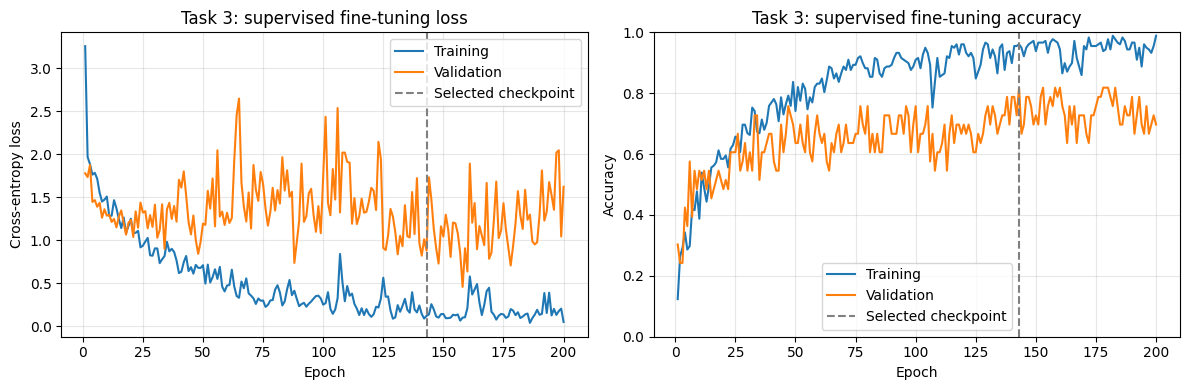

Fine-tuning and transfer results: {'selected_epoch': 143, 'validation_accuracy': 0.8181818181818182, 'validation_loss': 0.8773849299459746, 'test_accuracy': 0.7444444444444445, 'test_loss': 1.2130032075362074}
Use the curves and frozen-feature diagnostics to discuss transfer. A causal claim that pretraining improves performance requires a matched randomly initialized baseline with the same fine-tuning protocol.


In [ ]:
################################################################################
# TODO: (for later analysis)
# Write your own code to visualize the training and validation loss and
# accuracy across fine-tuning epochs
################################################################################

analysis_dir_task3 = os.path.join(weights_root, 'task3_analysis')
os.makedirs(analysis_dir_task3, exist_ok=True)
epoch_axis_ft = np.arange(1, len(history_ft['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epoch_axis_ft, history_ft['train_loss'], label='Training')
axes[0].plot(epoch_axis_ft, history_ft['val_loss'], label='Validation')
axes[0].set(title='Task 3: supervised fine-tuning loss', ylabel='Cross-entropy loss')
axes[1].plot(epoch_axis_ft, history_ft['train_accuracy'], label='Training')
axes[1].plot(epoch_axis_ft, history_ft['val_accuracy'], label='Validation')
axes[1].set(title='Task 3: supervised fine-tuning accuracy', ylabel='Accuracy', ylim=(0, 1))
for ax in axes:
    ax.axvline(selection_ft['best_epoch'], color='gray', linestyle='--',
               label='Selected checkpoint')
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(analysis_dir_task3, 'finetuning_curves.png'), dpi=200)
plt.show()
transfer_summary_task3 = {
    'selected_epoch': selection_ft['best_epoch'],
    'validation_accuracy': selection_ft['val_accuracy'],
    'validation_loss': selection_ft['val_loss'],
    'test_accuracy': float(results_ft['accuracy']),
    'test_loss': float(results_ft['loss']),
}
with open(os.path.join(analysis_dir_task3, 'transfer_summary.json'),
          'w', encoding='utf-8') as file:
    json.dump(transfer_summary_task3, file, indent=2)
print('Fine-tuning and transfer results:', transfer_summary_task3)
print('Use the curves and frozen-feature diagnostics to discuss transfer. '
      'A causal claim that pretraining improves performance requires a '
      'matched randomly initialized baseline with the same fine-tuning protocol.')

################################################################################
#                         END OF YOUR CODE
################################################################################

### **[15%] Task 3 - Analysis Report**

Please present the following analysis in the separate PDF report. Include the resulting figures and numerical evidence, but keep all code in the notebook.

- **A3.1 - Contrastive-pair and augmentation analysis [5%]:** Show several positive pairs produced by your dataset and discuss whether your augmentations preserve information needed to recognize the instrument. Explain both the intended benefit and any risk introduced by the transformations you selected.

- **A3.2 - Learned-representation analysis [5%]:** Use the frozen pretrained encoder to analyse its learned representations. Perform the main representation analysis using the labelled training split, and use the validation split to examine whether the observed representation structure generalizes to unseen images. Design appropriate visualizations and/or quantitative diagnostics to investigate: (1) whether different augmented views of the same image are close in feature space; and (2) whether images from the same instrument class tend to be more closely grouped than images from different classes. Possible approaches include but not limited to similarity distributions, nearest-neighbour analysis, feature-space visualization, etc. Interpret the observed structure, class patterns, and representative failure cases.

- **A3.3 - Fine-tuning and transfer analysis [5%]:** Present the training and validation loss and accuracy across fine-tuning epochs, then discuss convergence, stability, and evidence of overfitting or underfitting. Report the validation performance used for checkpoint selection and the final performance of the selected checkpoint on the test set. Explain what the results suggest about transferring the contrastively pretrained encoder to instrument classification.